# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 18     |  |
| :-------------|:-------------|
| Tim Mekkelholt| 6224687 |
| Laura Otto | 6488463 |
| Justin Sloots | 6541313 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Tim', 'Laura','Justin']

## Opdracht 1: Planning.

| Planning Groep: 18     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibratie sensor gedaan | 11:30 |
| Eerste testmeting gedaan | 12:00 |
| Meetplan uitwerken | 12:00-12:30 |
| Optestellen/eerste meting| 13:45-14:45 |
| Iteraties uitvoeren | 15:00-16:30 |
| Algoritme presenteren | 16:30-17:00 |
| Afronden en opruimen | 17:00-17:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 14:45-15:00 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit
# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep 18
<img src="Kalibratieopstelling.jpg" width="400">

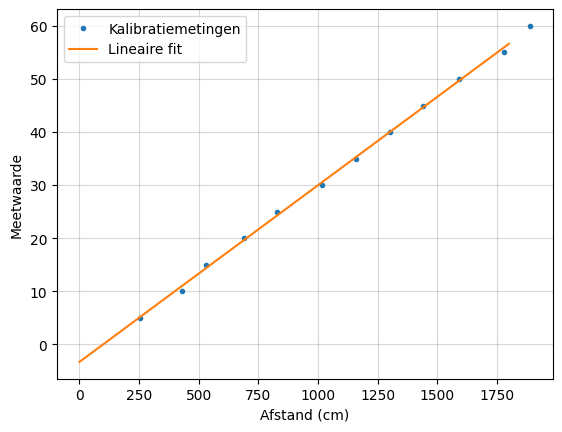

De parameters van de lineaire fit zijn: a = 0.0333, b = -3.33


In [3]:
# verwerk hier jullie kalibratiemetingen
afstanden = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60])
meetwaarden = np.array([253, 430, 530, 690, 830, 1015, 1160, 1300, 1440, 1590, 1780, 1890])

def line (x, a, b):
    return a*x + b
x_fit = np.linspace(0, 1800, 1000)

popt, pcov = curve_fit(line, meetwaarden, afstanden)


plt.figure()
plt.plot( meetwaarden,afstanden, '.', label='Kalibratiemetingen')
plt.plot( x_fit, line(x_fit, popt[0], popt[1]), label='Lineaire fit')
plt.xlabel('Afstand (cm)')  
plt.ylabel('Meetwaarde')
plt.grid(alpha=0.5)
plt.legend()
plt.show()
print(f"De parameters van de lineaire fit zijn: a = {popt[0]:.4f}, b = {popt[1]:.2f}")



## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  45.0
1   0  30   0  20  43.5
2  40   0  30   0  48.5
3  30   0  20   0  46.2


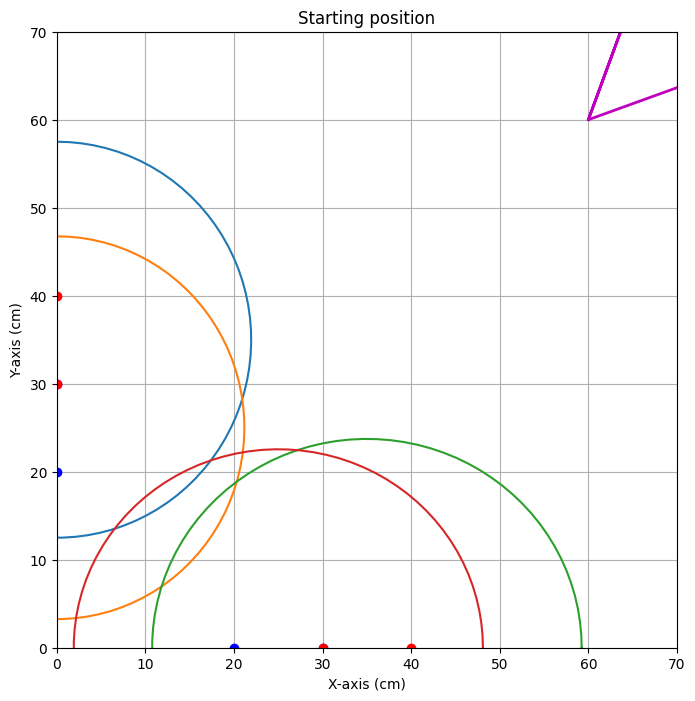


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=96.155


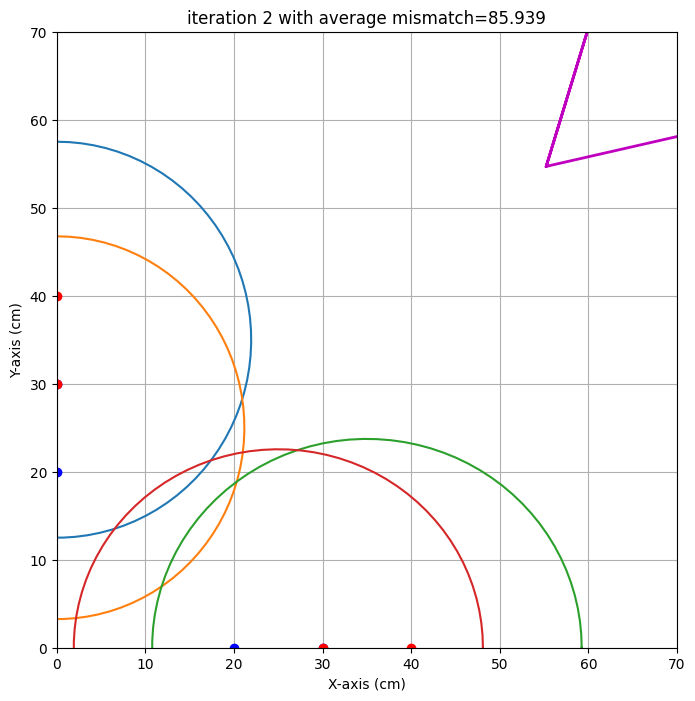

end iteration 2 with average mismatch=85.939


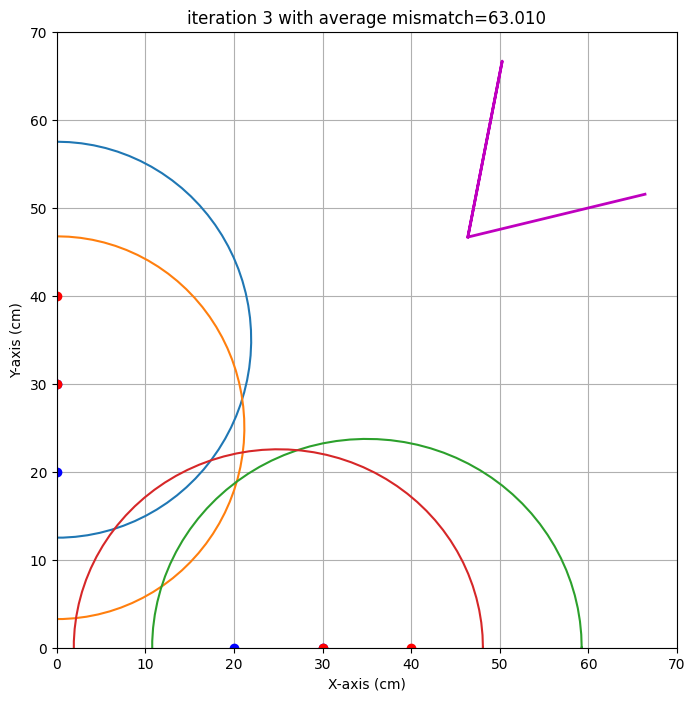

end iteration 3 with average mismatch=63.010


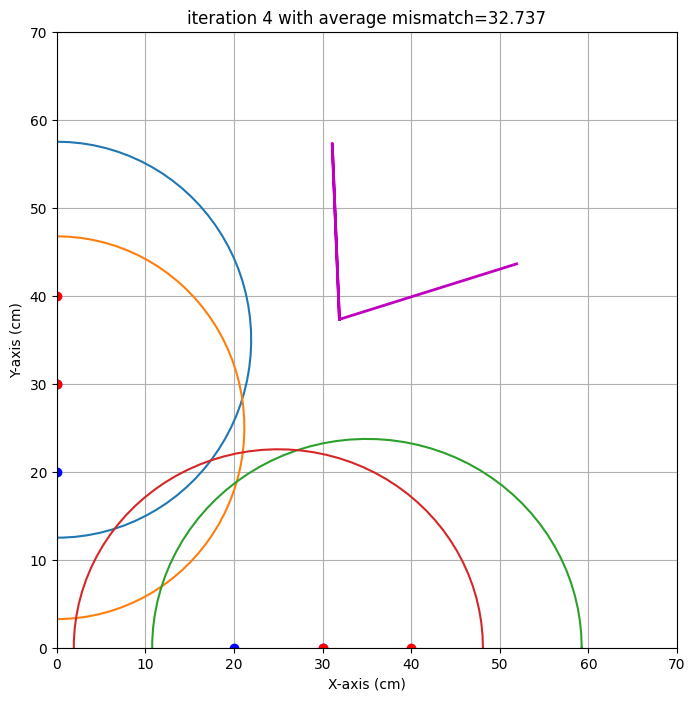

end iteration 4 with average mismatch=32.737


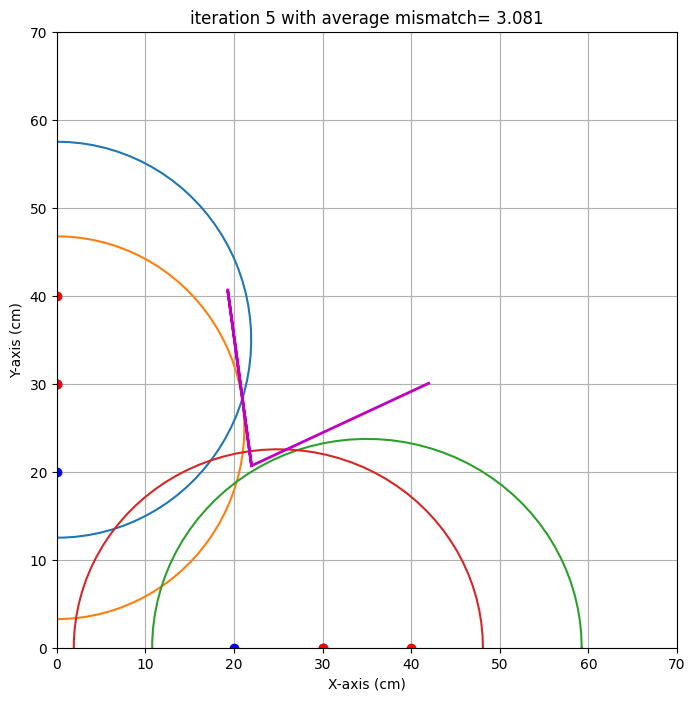

end iteration 5 with average mismatch= 3.081


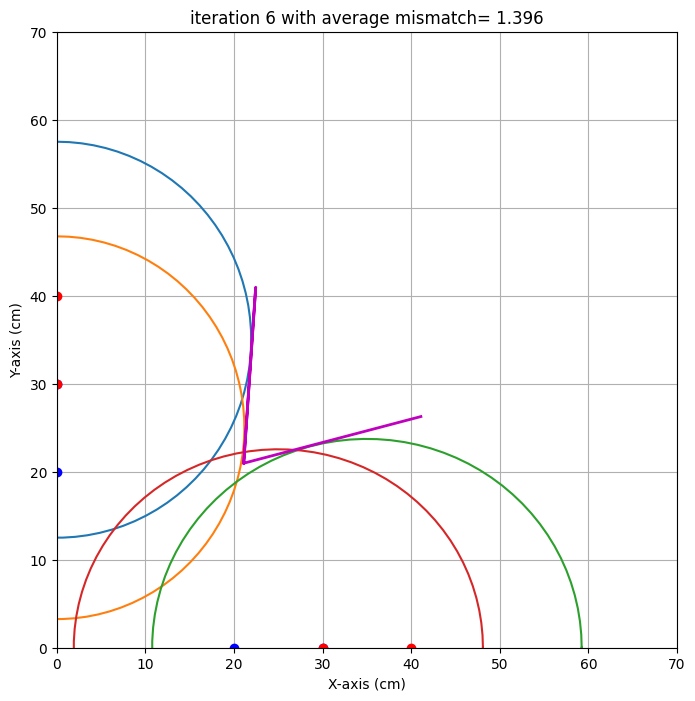

end iteration 6 with average mismatch= 1.396


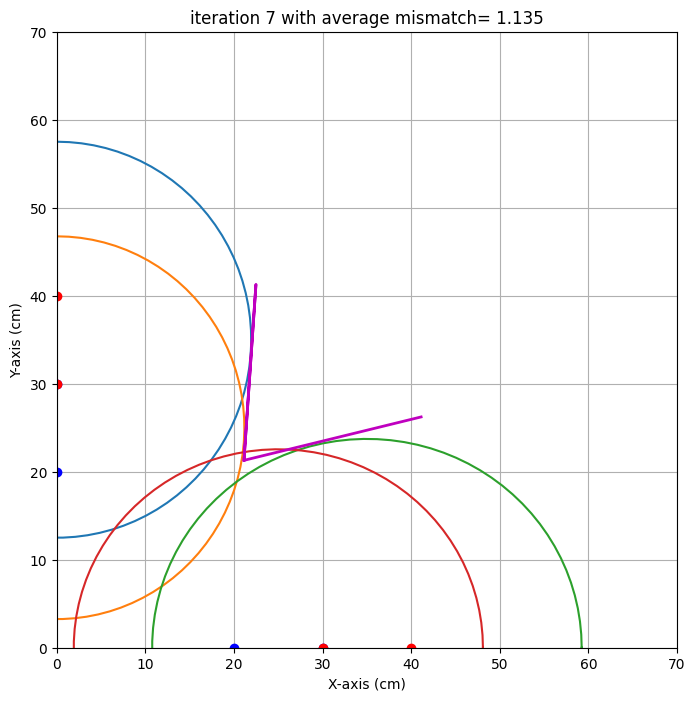

end iteration 7 with average mismatch= 1.135


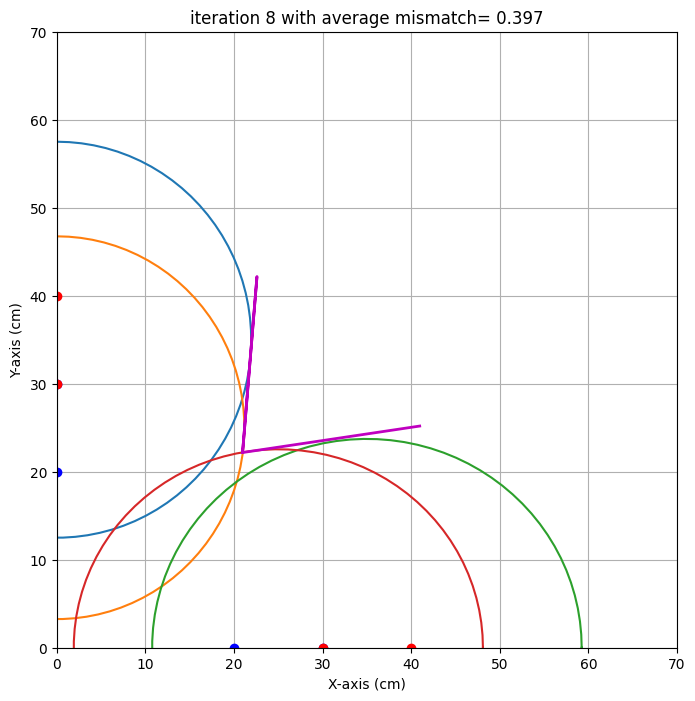

end iteration 8 with average mismatch= 0.397
end iteration 9 with average mismatch= 0.396
end iteration 10 with average mismatch= 0.396
end iteration 11 with average mismatch= 0.396


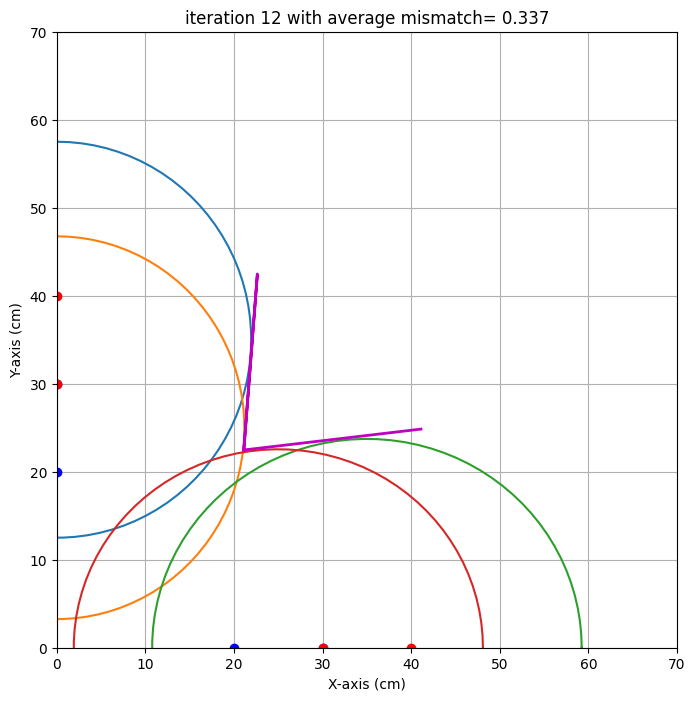

end iteration 12 with average mismatch= 0.337


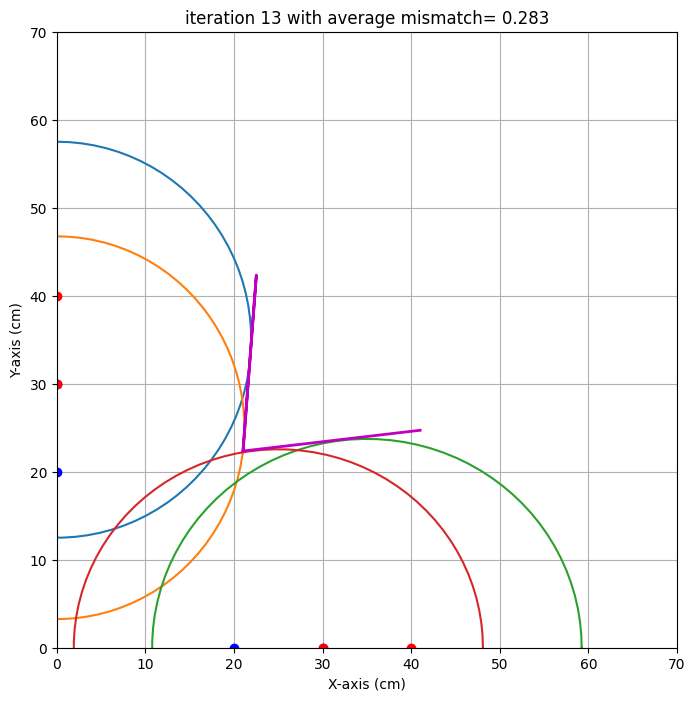

end iteration 13 with average mismatch= 0.283


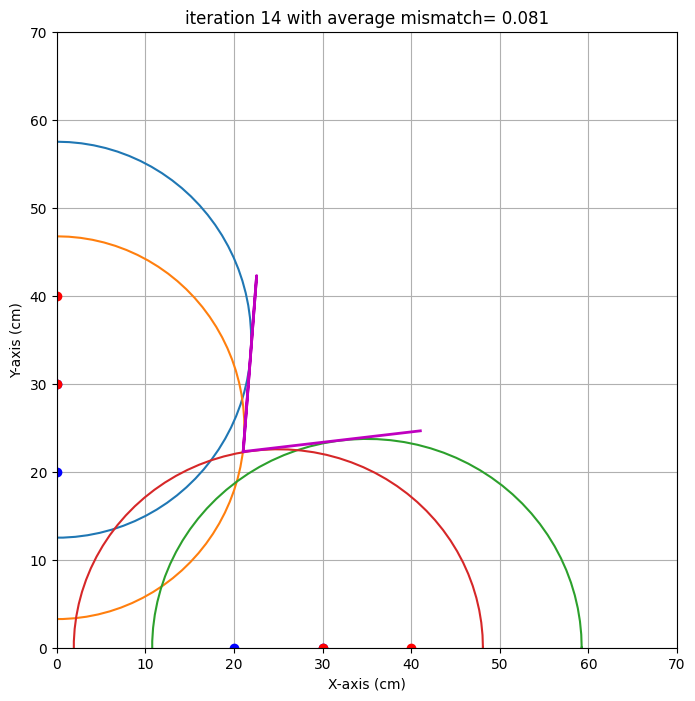

end iteration 14 with average mismatch= 0.081
end iteration 15 with average mismatch= 0.073
end iteration 16 with average mismatch= 0.070
end iteration 17 with average mismatch= 0.068
end iteration 18 with average mismatch= 0.068
end iteration 19 with average mismatch= 0.068
end iteration 20 with average mismatch= 0.068
end iteration 21 with average mismatch= 0.068
end iteration 22 with average mismatch= 0.068
end iteration 23 with average mismatch= 0.068
end iteration 24 with average mismatch= 0.068
end iteration 25 with average mismatch= 0.068
end iteration 26 with average mismatch= 0.068
end iteration 27 with average mismatch= 0.068
end iteration 28 with average mismatch= 0.068
end iteration 29 with average mismatch= 0.068
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.068
###############################################################################
end of iteration  30
Best alp

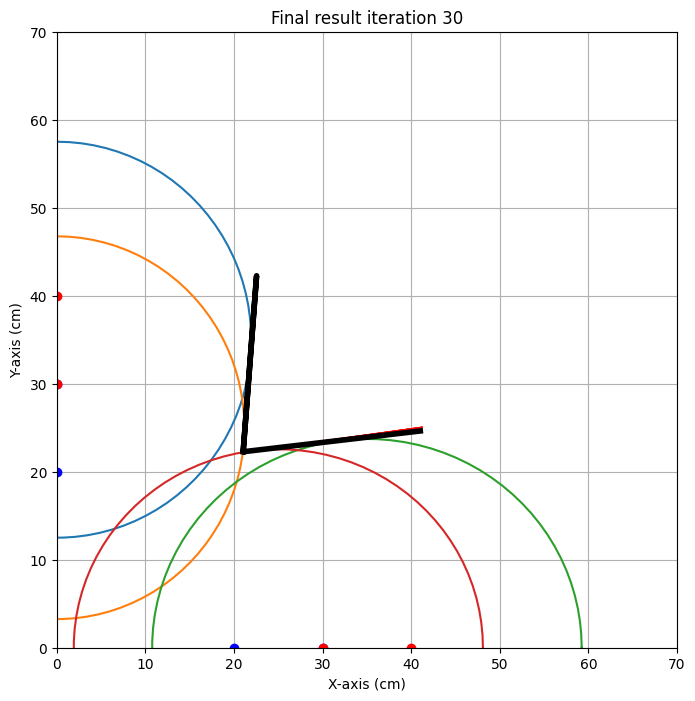

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,45.0],
    [0,30,0,20,43.5],
    #[0,10,0,20,135.0],
    [40,0,30,0,48.5],
    [30,0,20,0,46.2],
    #[10,0,20,0,190],
    #[10,0,0,10,150]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.0 cm met een standaardafwijking van 0.2 cm 
y0: 22.3 cm met een standaardafwijking van 0.0 cm 
alpha: 6.7 graden met een standaardafwijking van 1.2 graad 
beta: 4.3 graden met een standaardafwijking van 1.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme Justin
<img src="algoritme3.jpg" width="400">

#### algoritme Laura
<img src="Algoritme2.jpg" width="400">

#### algoritme Tim
<img src="Algoritme1.jpg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 29,
           'y0': 43,
           'alpha' : 0, 
           'beta' : 29, 
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Tim' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40, 0, 30, 0, 87.0],
    [35, 0, 25, 0, 86.5],
    [0, 68, 0, 58, 67.0],
    [0, 66, 0, 56, 84.0],
    ]),
       'Laura' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [42, 0, 33, 0, 86.0],
    [47, 0, 38, 0, 84.2],
    [0, 51, 0, 68, 73],
    [0, 52, 0, 67, 71]
    ]),
       'Justin' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [20, 0, 30, 0, 86.7],
    [25, 0, 35, 0, 85.0],
    [0, 52, 0, 62, 66],
    [0, 57, 0, 67, 66],
    ])
      }

## Opdracht 7: Evaluatie.

Tim
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  30   0  87.0
1  35   0  25   0  86.5
2   0  68   0  58  67.0
3   0  66   0  56  84.0


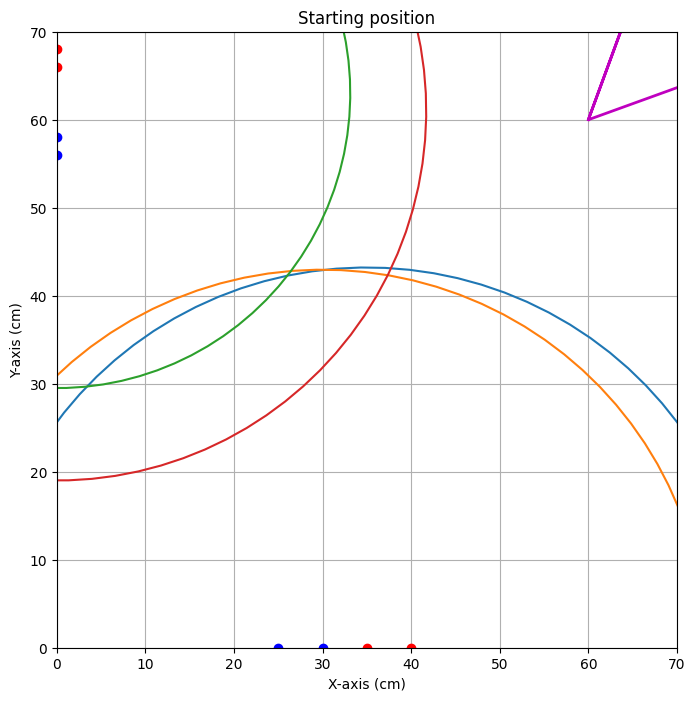


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=50.386


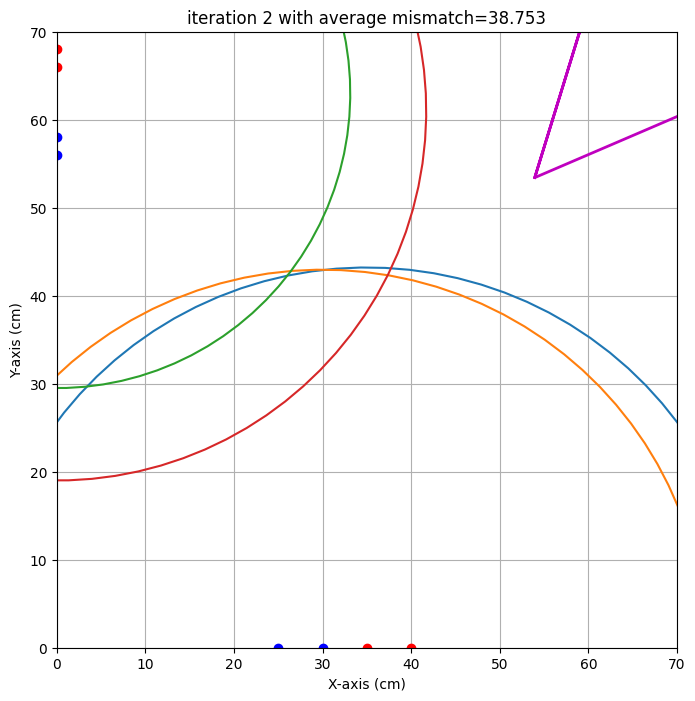

end iteration 2 with average mismatch=38.753


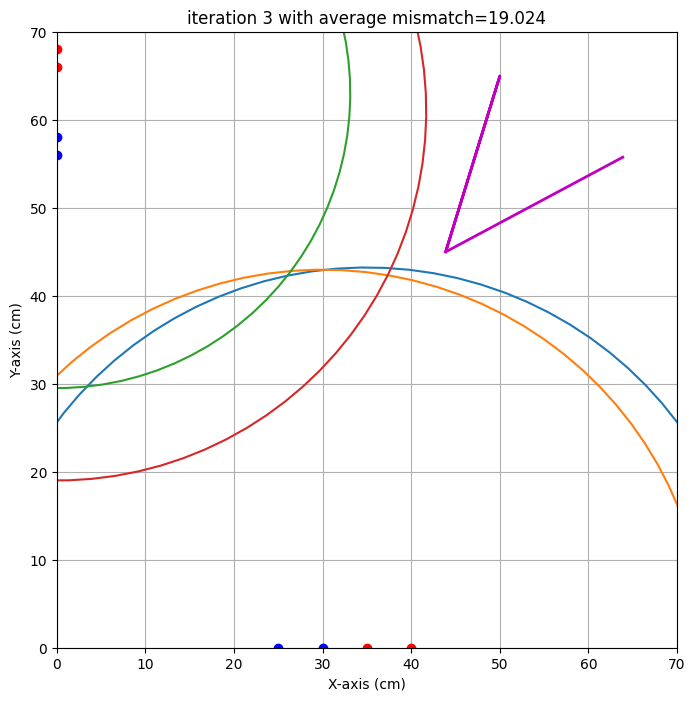

end iteration 3 with average mismatch=19.024


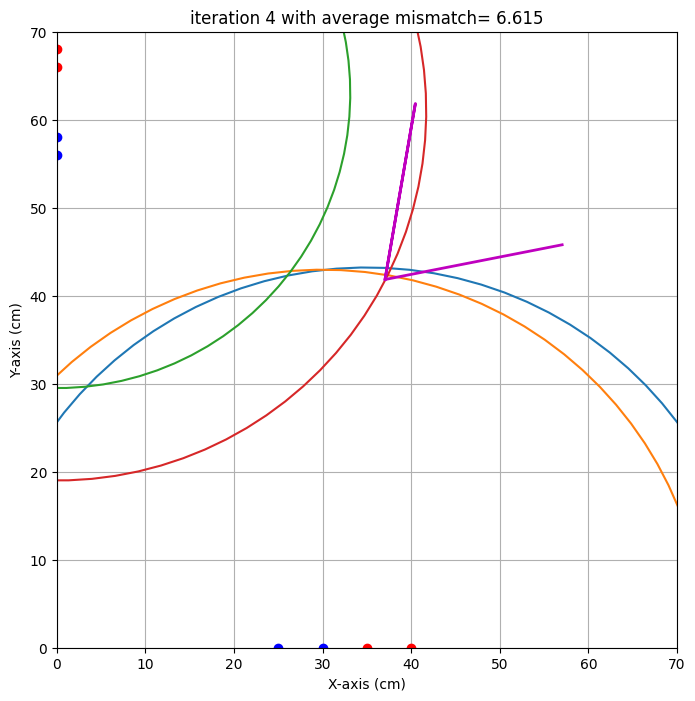

end iteration 4 with average mismatch= 6.615
end iteration 5 with average mismatch= 6.422


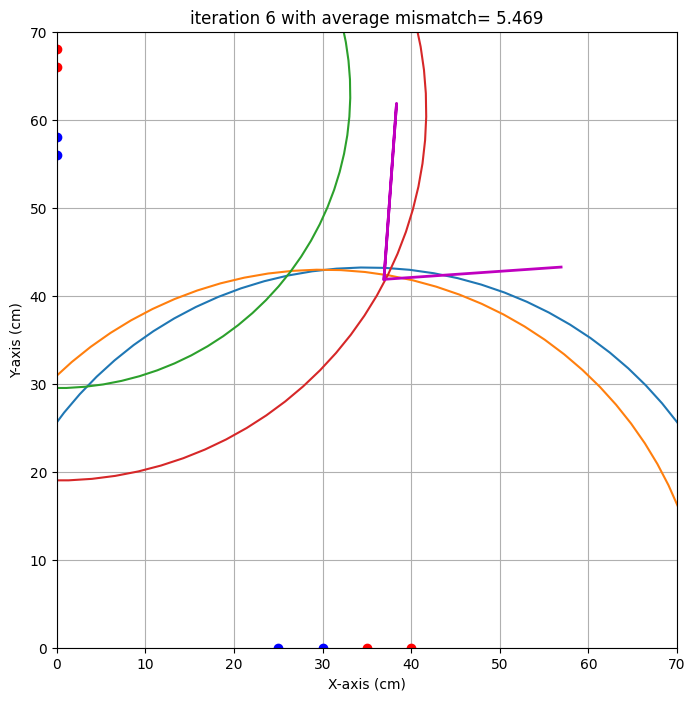

end iteration 6 with average mismatch= 5.469
end iteration 7 with average mismatch= 5.469
end iteration 8 with average mismatch= 5.148
end iteration 9 with average mismatch= 5.148
end iteration 10 with average mismatch= 5.148
end iteration 11 with average mismatch= 5.148
end iteration 12 with average mismatch= 5.148
end iteration 13 with average mismatch= 5.148
end iteration 14 with average mismatch= 5.148
end iteration 15 with average mismatch= 5.148
end iteration 16 with average mismatch= 4.979
end iteration 17 with average mismatch= 4.553
end iteration 18 with average mismatch= 4.368
end iteration 19 with average mismatch= 4.368
end iteration 20 with average mismatch= 4.350
end iteration 21 with average mismatch= 4.303
end iteration 22 with average mismatch= 4.302
end iteration 23 with average mismatch= 4.302
end iteration 24 with average mismatch= 4.302
end iteration 25 with average mismatch= 4.302
end iteration 26 with average mismatch= 4.302
end iteration 27 with average mismatch

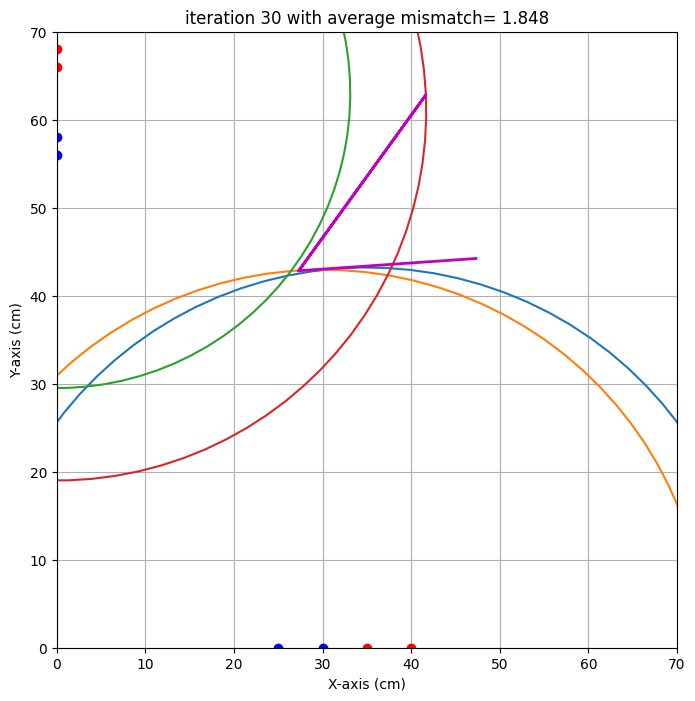

end iteration 30 with average mismatch= 1.848
###############################################################################
end of iteration  30
Best alpha=   3.99 with uncertainty=   2.75
Best beta =  35.68 with uncertainty=   0.90
Best x0   =  27.30 with uncertainty=   0.14
Best y0   =  42.84 with uncertainty=   0.58
###############################################################################


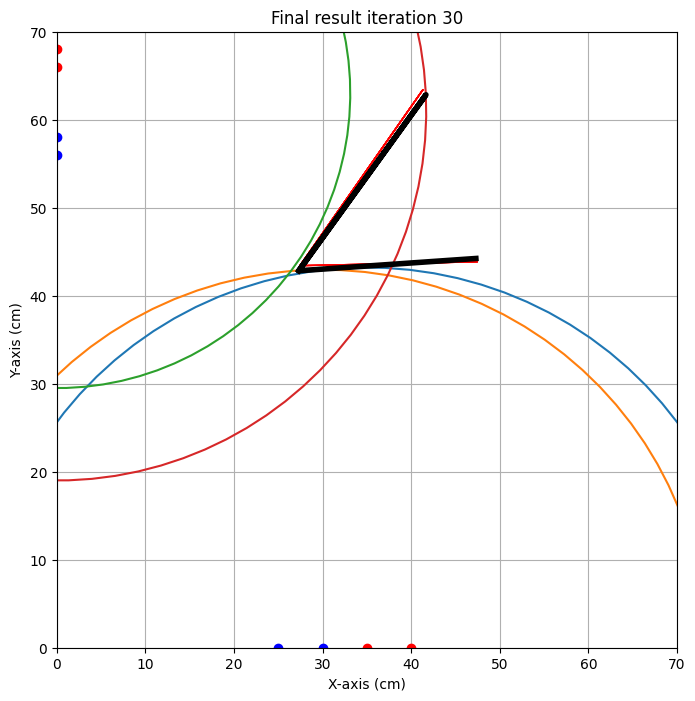

{'alpha': np.float64(3.9909490273141124), 'alpha_eps': np.float64(2.7453077123474805), 'beta': np.float64(35.68132490796153), 'beta_eps': np.float64(0.904368043271532), 'x0': np.float64(27.303781992164883), 'x0_eps': np.float64(0.1350250794071357), 'y0': np.float64(42.83649290934608), 'y0_eps': np.float64(0.5802515556414107)}
Laura
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  42   0  33   0  86.0
1  47   0  38   0  84.2
2   0  51   0  68  73.0
3   0  52   0  67  71.0


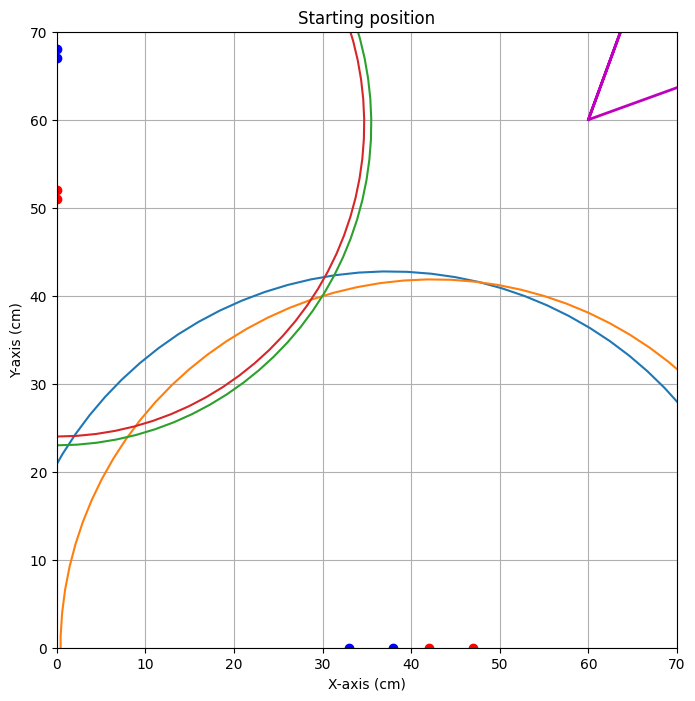


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=50.798


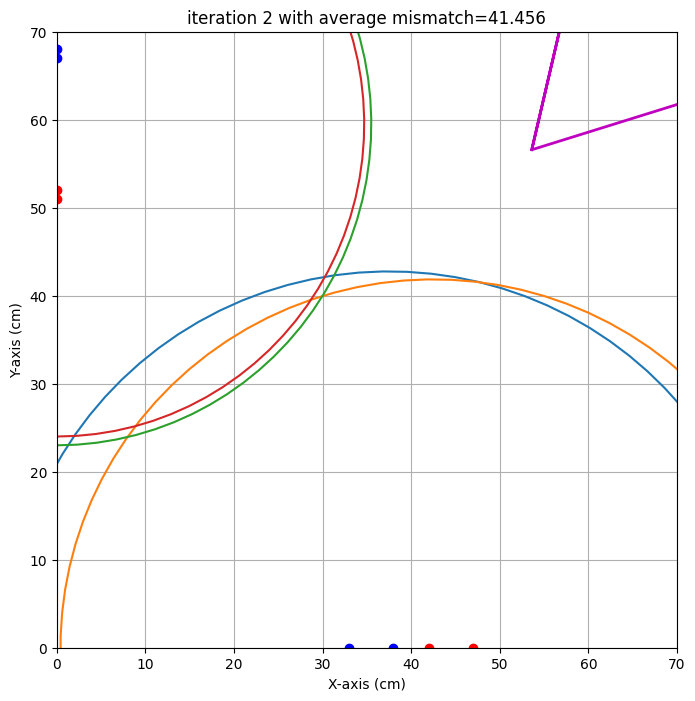

end iteration 2 with average mismatch=41.456


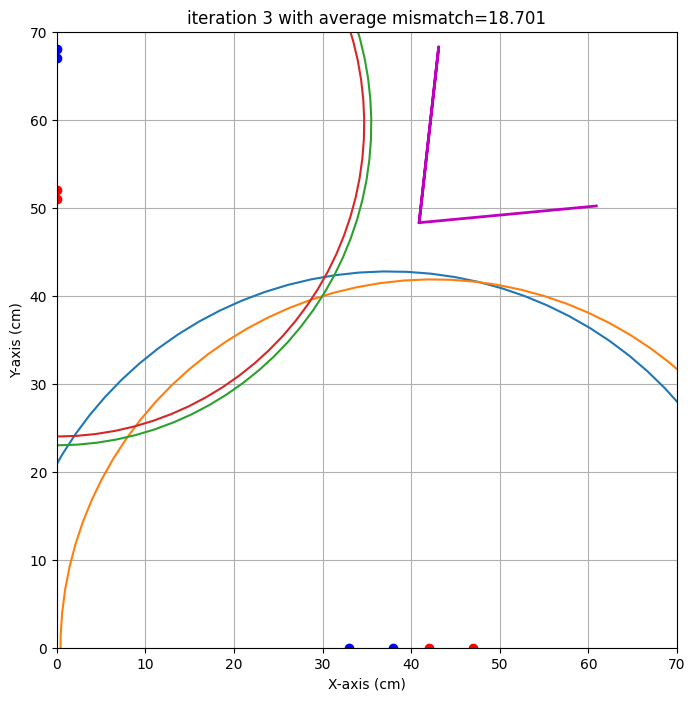

end iteration 3 with average mismatch=18.701


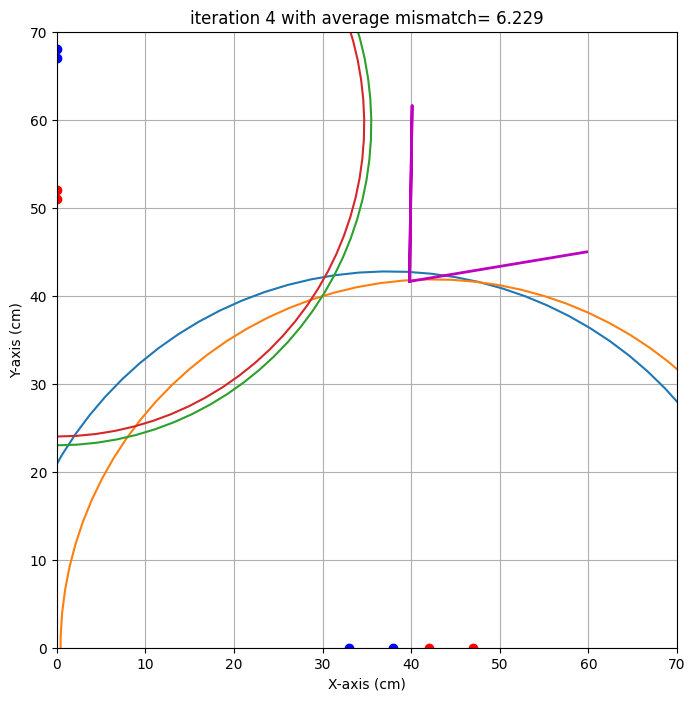

end iteration 4 with average mismatch= 6.229


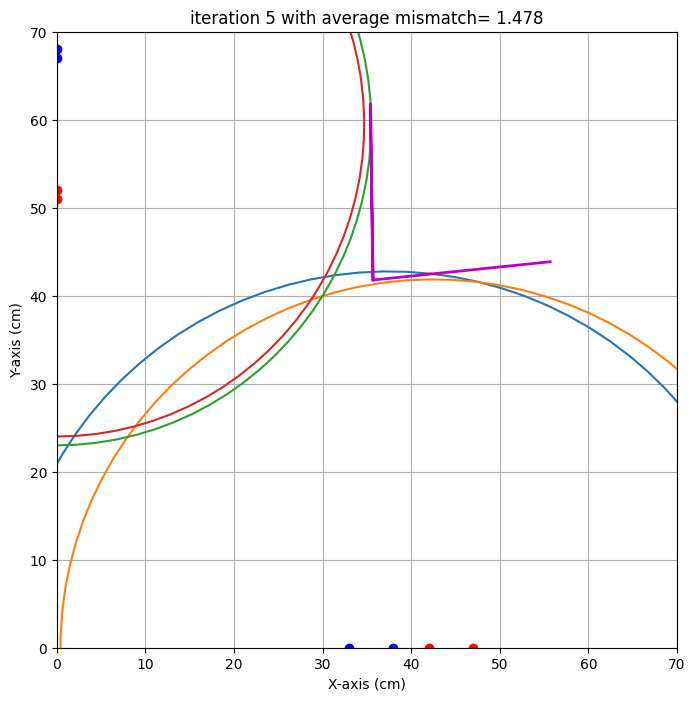

end iteration 5 with average mismatch= 1.478
end iteration 6 with average mismatch= 1.387
end iteration 7 with average mismatch= 1.305


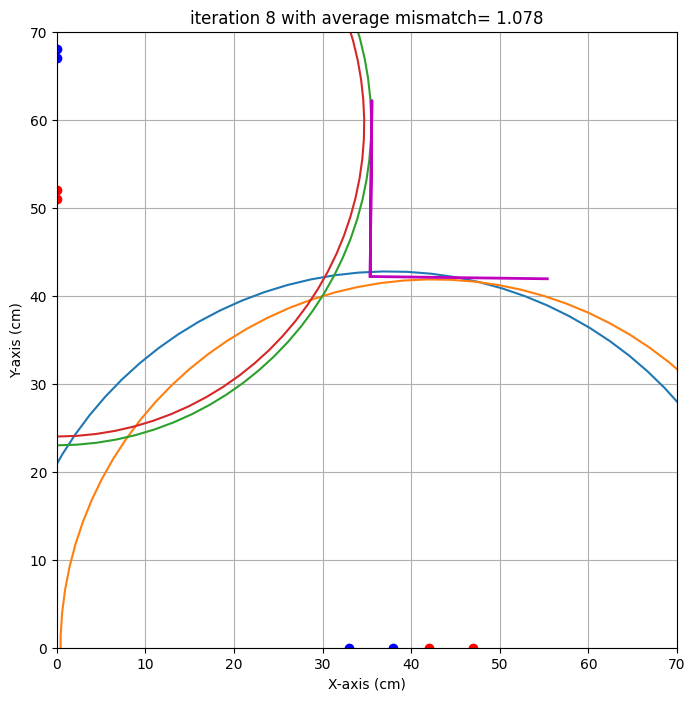

end iteration 8 with average mismatch= 1.078
end iteration 9 with average mismatch= 0.980
end iteration 10 with average mismatch= 0.980


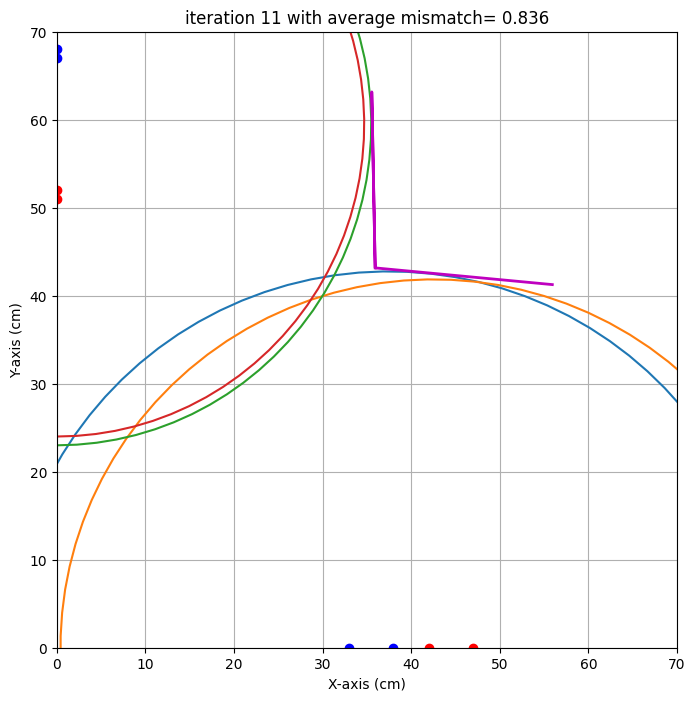

end iteration 11 with average mismatch= 0.836


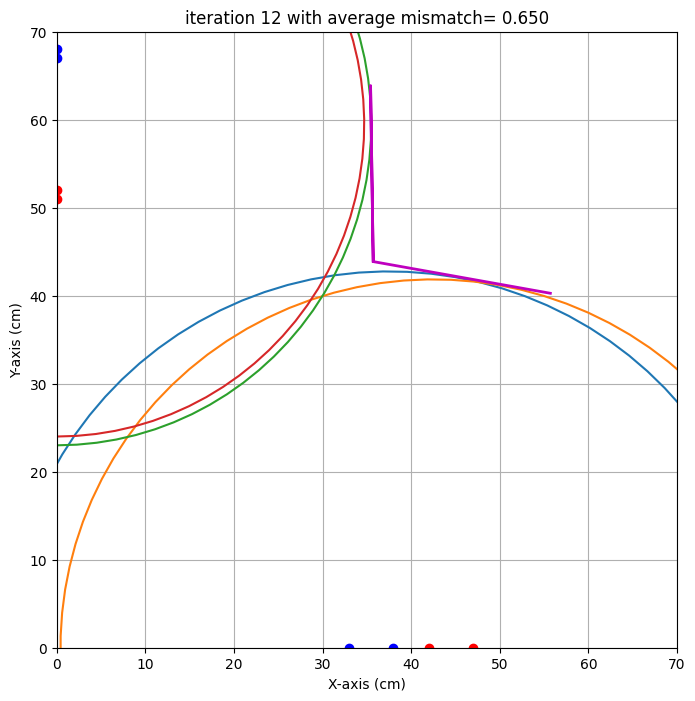

end iteration 12 with average mismatch= 0.650


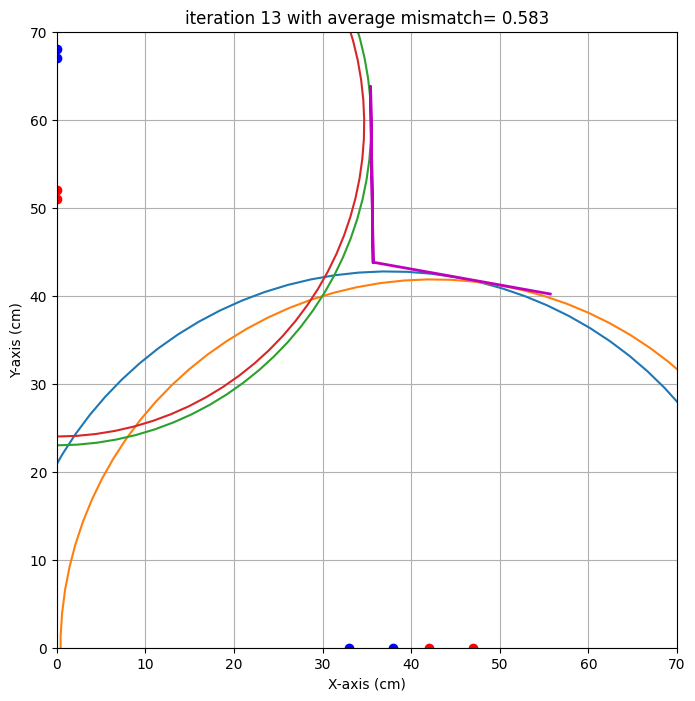

end iteration 13 with average mismatch= 0.583
end iteration 14 with average mismatch= 0.566
end iteration 15 with average mismatch= 0.565
end iteration 16 with average mismatch= 0.565
end iteration 17 with average mismatch= 0.565
end iteration 18 with average mismatch= 0.565
end iteration 19 with average mismatch= 0.565
end iteration 20 with average mismatch= 0.565
end iteration 21 with average mismatch= 0.565
end iteration 22 with average mismatch= 0.565
end iteration 23 with average mismatch= 0.547
end iteration 24 with average mismatch= 0.525
end iteration 25 with average mismatch= 0.517
end iteration 26 with average mismatch= 0.515
end iteration 27 with average mismatch= 0.515
end iteration 28 with average mismatch= 0.477
end iteration 29 with average mismatch= 0.438
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.437
###############################################################

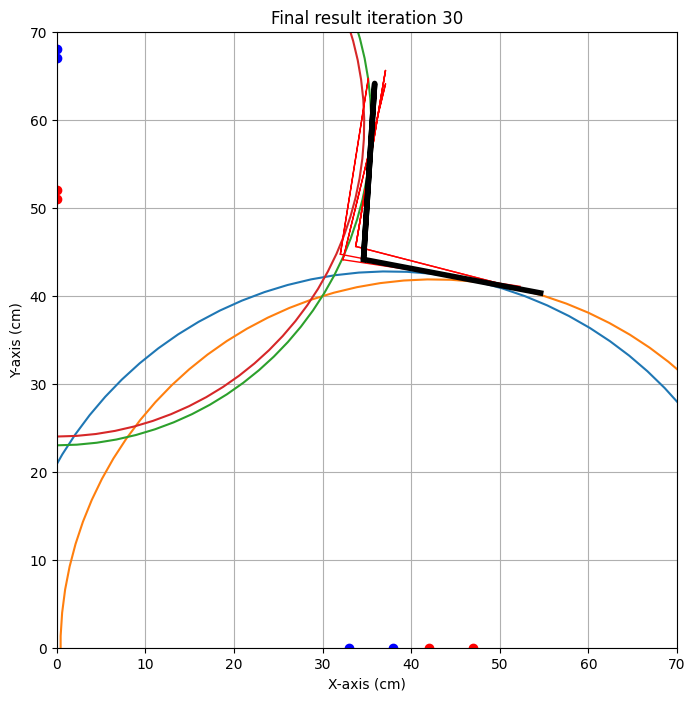

{'alpha': np.float64(-10.804568788936663), 'alpha_eps': np.float64(3.7678913476959686), 'beta': np.float64(3.611479947294745), 'beta_eps': np.float64(9.92307351828311), 'x0': np.float64(34.614345693853146), 'x0_eps': np.float64(2.611913716205663), 'y0': np.float64(44.12374314286675), 'y0_eps': np.float64(1.4776708149182411)}
Justin
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  20   0  30   0  86.7
1  25   0  35   0  85.0
2   0  52   0  62  66.0
3   0  57   0  67  66.0


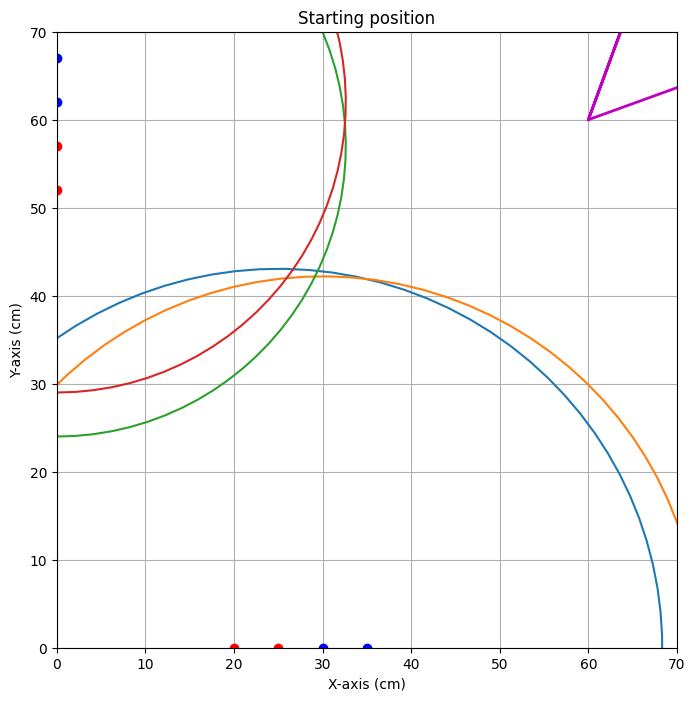


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=57.915


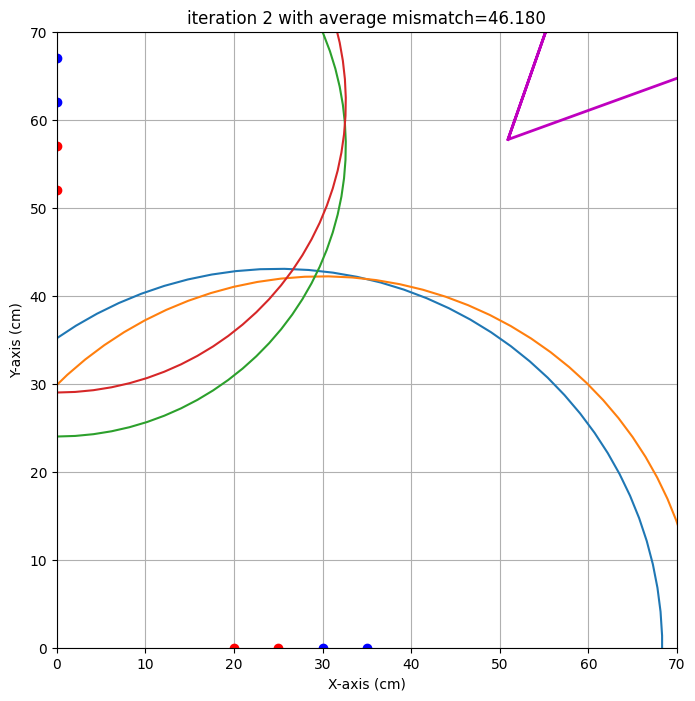

end iteration 2 with average mismatch=46.180


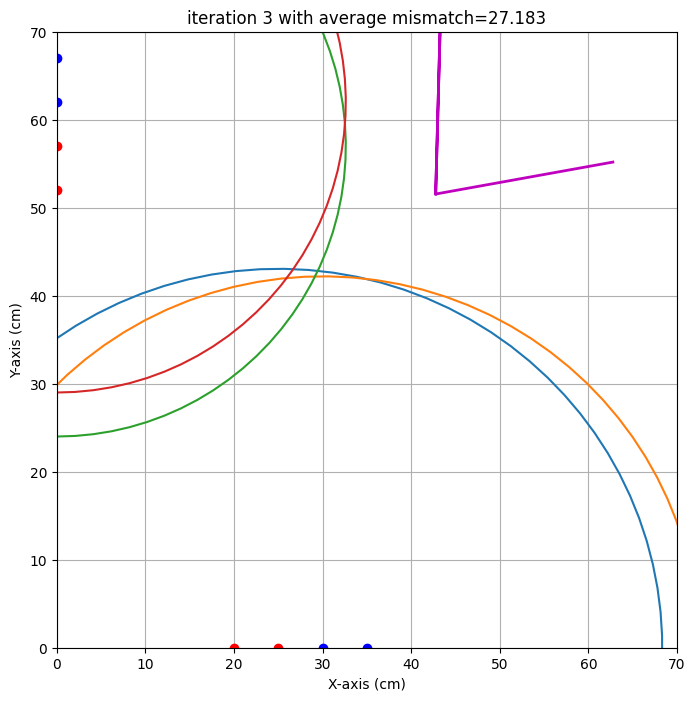

end iteration 3 with average mismatch=27.183


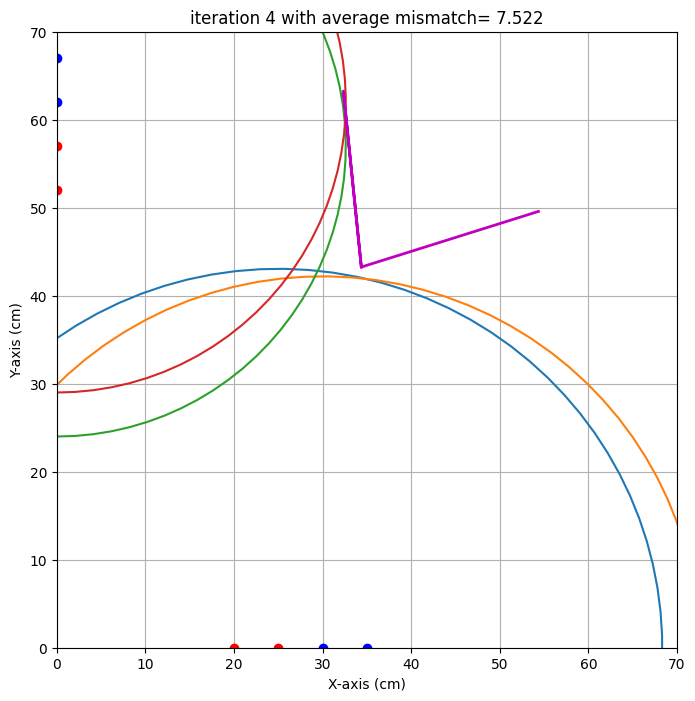

end iteration 4 with average mismatch= 7.522


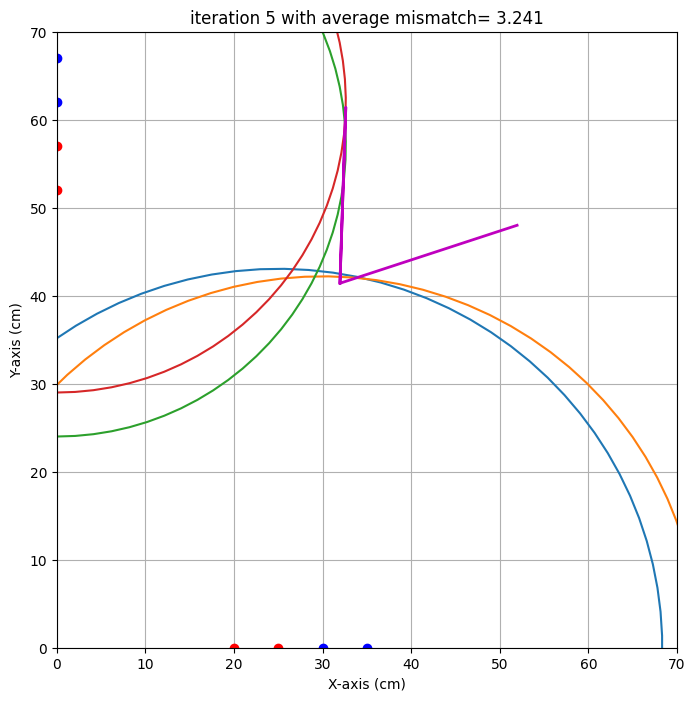

end iteration 5 with average mismatch= 3.241


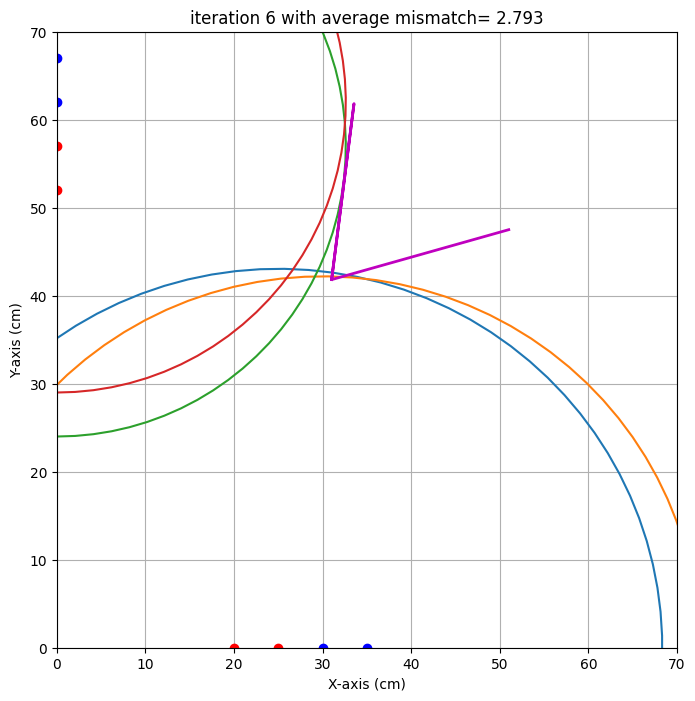

end iteration 6 with average mismatch= 2.793


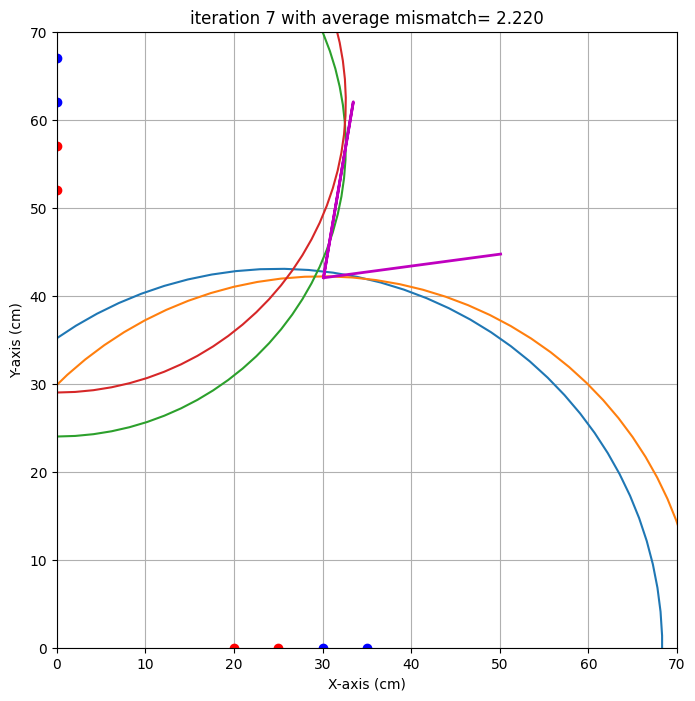

end iteration 7 with average mismatch= 2.220


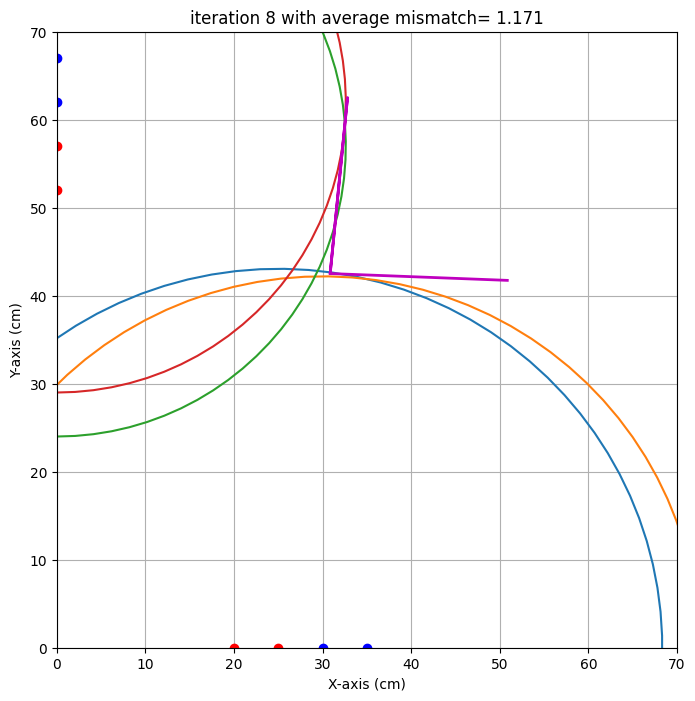

end iteration 8 with average mismatch= 1.171


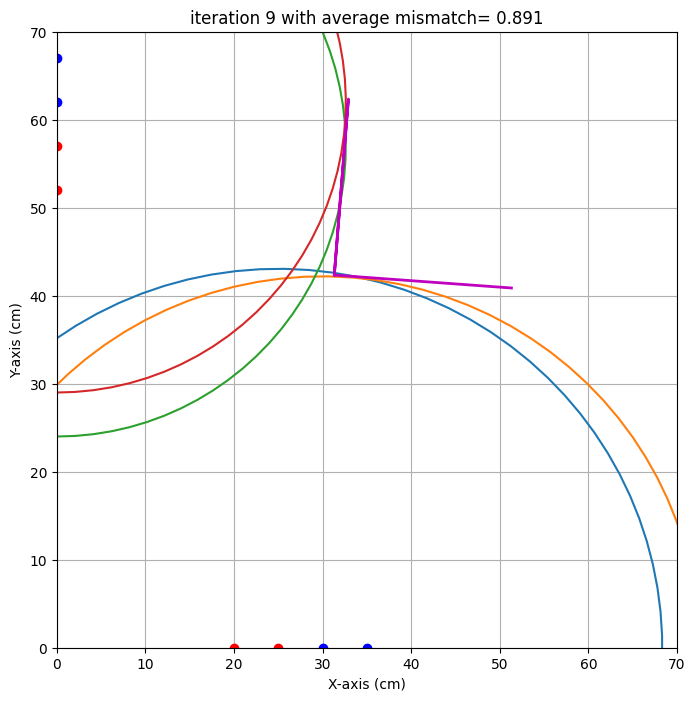

end iteration 9 with average mismatch= 0.891
end iteration 10 with average mismatch= 0.890


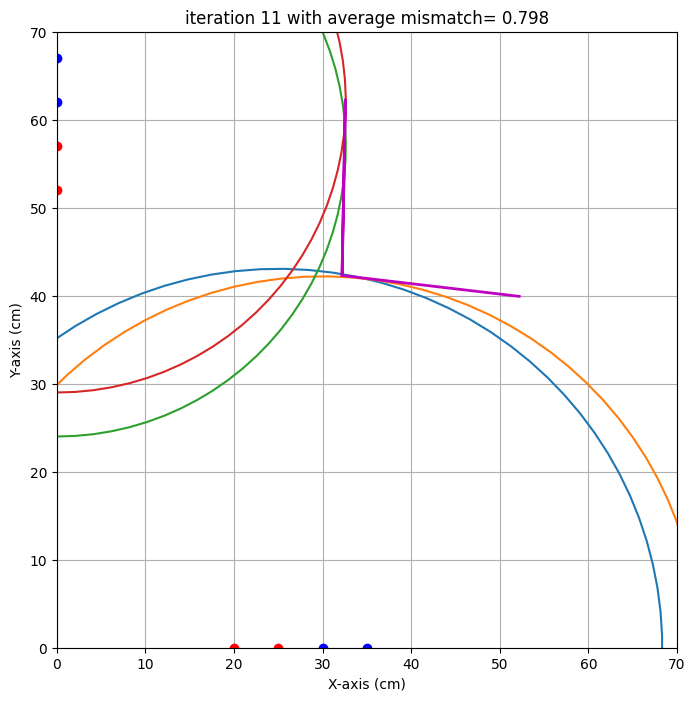

end iteration 11 with average mismatch= 0.798


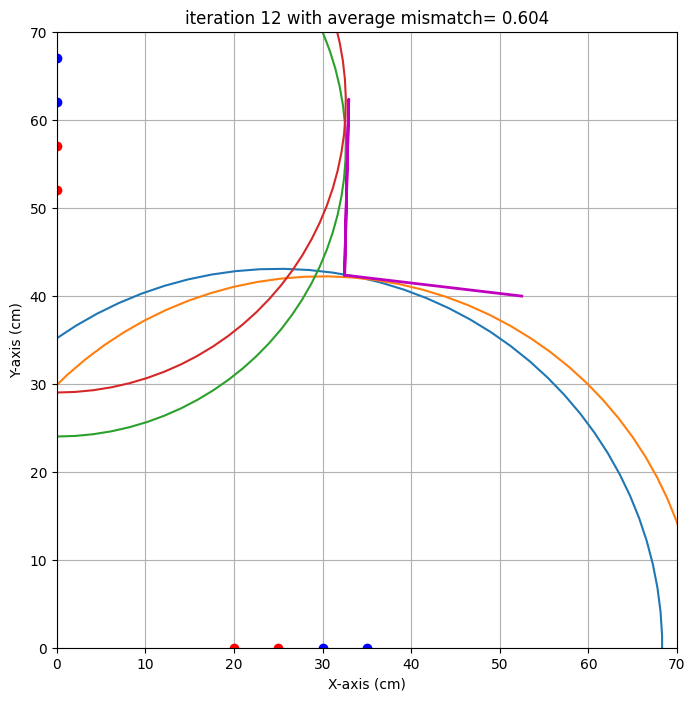

end iteration 12 with average mismatch= 0.604
end iteration 13 with average mismatch= 0.584


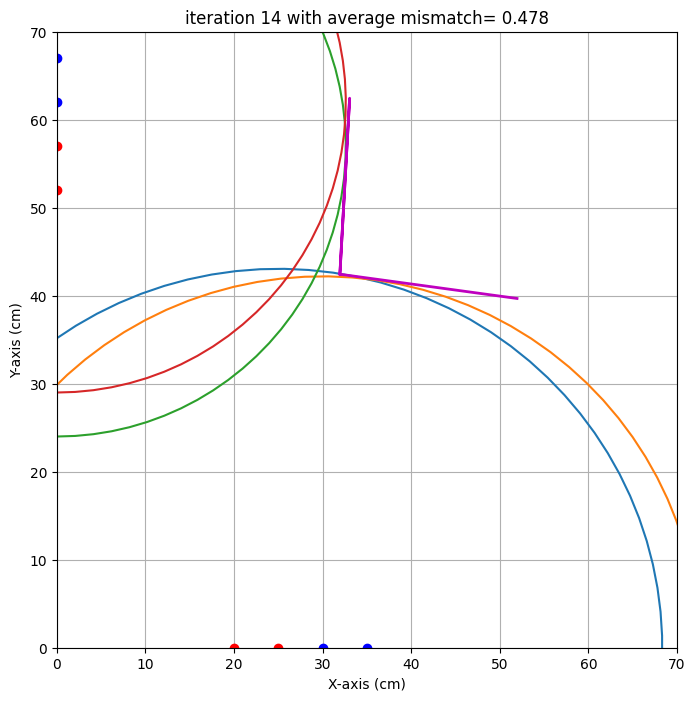

end iteration 14 with average mismatch= 0.478
end iteration 15 with average mismatch= 0.463
end iteration 16 with average mismatch= 0.462
end iteration 17 with average mismatch= 0.462
end iteration 18 with average mismatch= 0.459


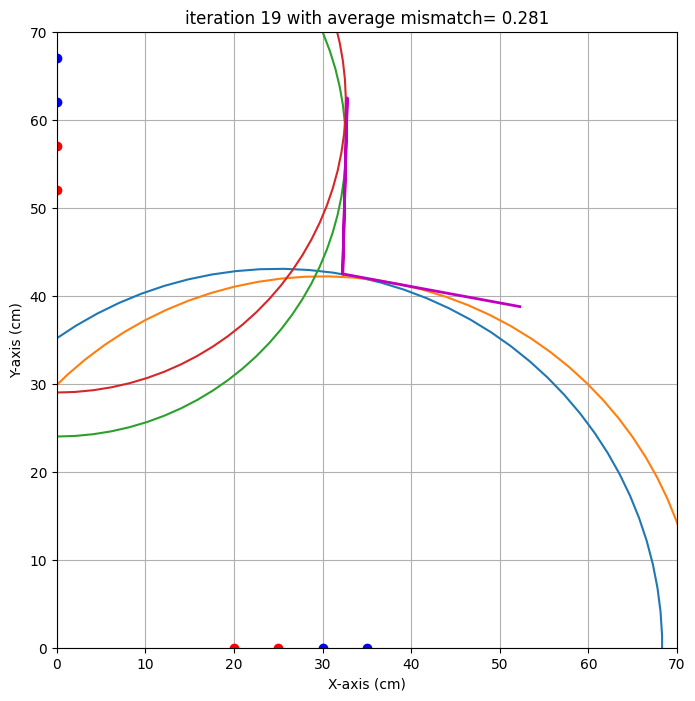

end iteration 19 with average mismatch= 0.281
end iteration 20 with average mismatch= 0.279
end iteration 21 with average mismatch= 0.271
end iteration 22 with average mismatch= 0.271
end iteration 23 with average mismatch= 0.262


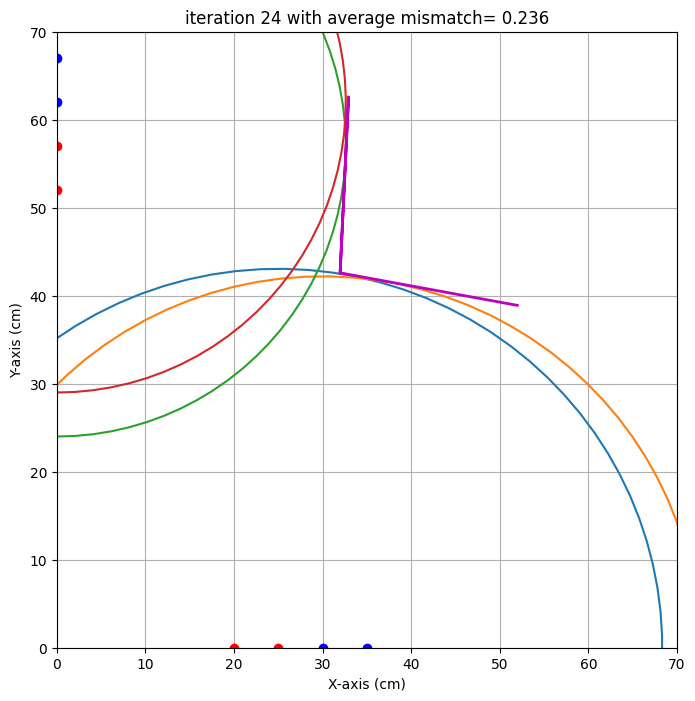

end iteration 24 with average mismatch= 0.236
end iteration 25 with average mismatch= 0.223
end iteration 26 with average mismatch= 0.219
end iteration 27 with average mismatch= 0.217
end iteration 28 with average mismatch= 0.217
end iteration 29 with average mismatch= 0.217
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.217
###############################################################################
end of iteration  30
Best alpha= -10.47 with uncertainty=   0.71
Best beta =   2.72 with uncertainty=   1.25
Best x0   =  31.97 with uncertainty=   0.42
Best y0   =  42.59 with uncertainty=   0.17
###############################################################################


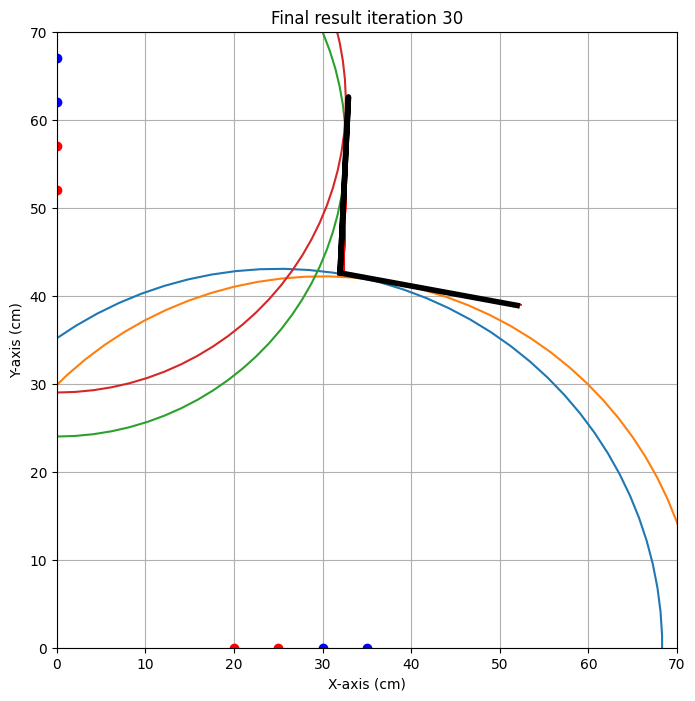

{'alpha': np.float64(-10.474897692241328), 'alpha_eps': np.float64(0.7132294815045572), 'beta': np.float64(2.7216902220349346), 'beta_eps': np.float64(1.2472190939729864), 'x0': np.float64(31.96650074835257), 'x0_eps': np.float64(0.41870862280511645), 'y0': np.float64(42.59273192994163), 'y0_eps': np.float64(0.1726337481014113)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Tim 
x0 target is : 29.0. Gevonden waarde: 27.3 cm met een standaardafwijking van 0.1 cm 
y0 target is : 43.0. Gevonden waarde: 42.8 cm met een standaardafwijking van 0.6 cm 
alpha target is : 0.0. Gevonden waarde: 4.0 graden met een standaardafwijking van 2.7 graad 
beta target is : 29.0. Gevonden waarde: 35.7 graden met een standaardafwijking van 0.9 graad 

Laura 
x0 target is : 29.0. Gevonden waarde: 34.6 cm met een standaardafwijking van 2.6 cm 
y0 target is : 43.0. Gevonden waarde: 44.1 cm met een standaardafwijking van 1.5 cm 
alpha target is : 0.0. Gevonden waarde: -10.8 graden met een standaardafwijking van 3.8 graad 
beta target is : 29.0. Gevonden waarde: 3.6 graden met een standaardafwijking van 9.9 graad 

Justin 
x0 target is : 29.0. Gevonden waarde: 32.0 cm met een standaardafwijking van 0.4 cm 
y0 target is : 43.0. Gevonden waarde: 42.6 cm met een standaardafwijking van 0.2 cm 
alpha target is : 0.0. Gevonden waarde: -10.5 graden met een standaardafwijking van 0.7 graad

## Opdracht 8: Iteratie1 15:00.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Iteratie 1: ![Alt](AlgoritmeFinal.jpg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  35   0  45   0  119.0
1  40   0  50   0  118.0
2   0  59   0  69   80.0
3   0  64   0  74   80.0
4   0  69   0  79   81.0
5  45   0  55   0  117.0


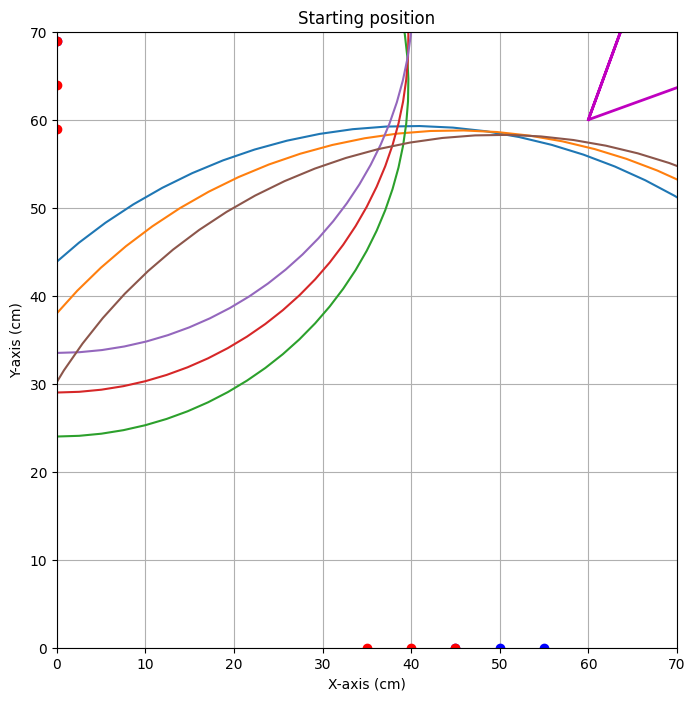


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=28.664


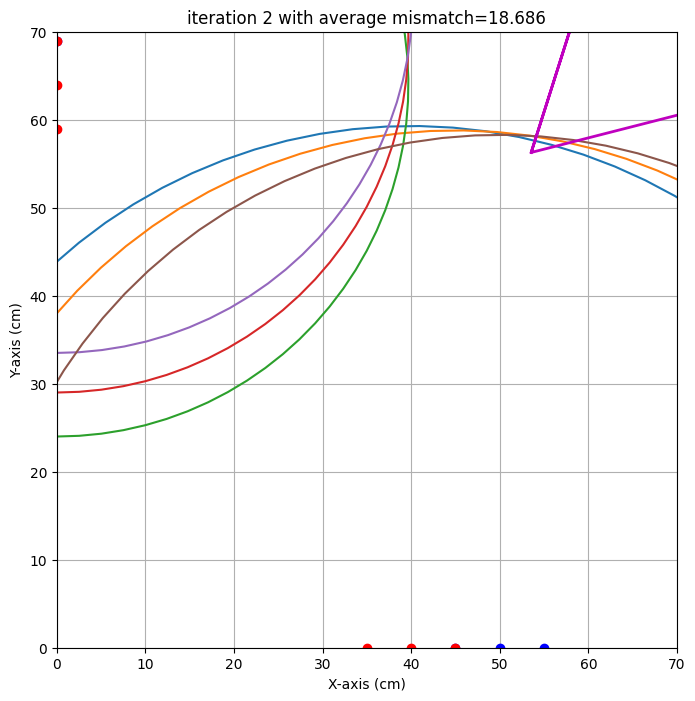

end iteration 2 with average mismatch=18.686


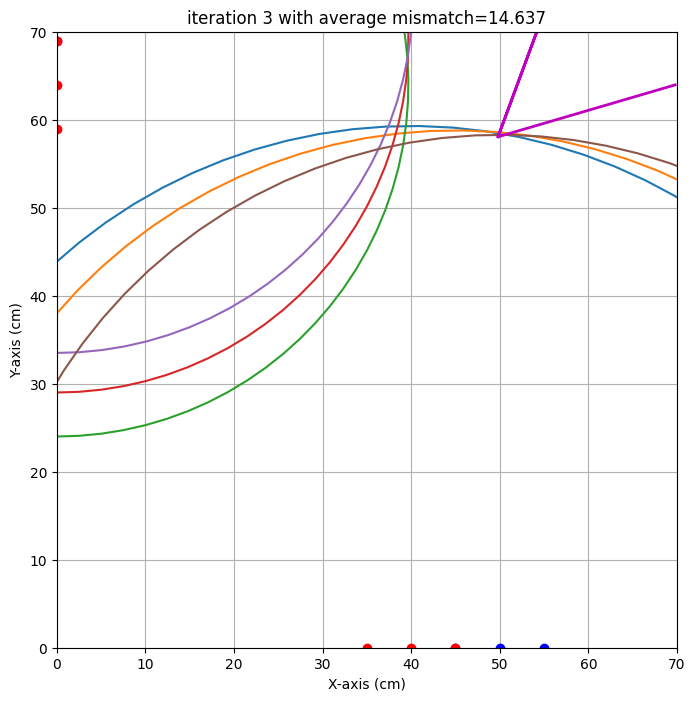

end iteration 3 with average mismatch=14.637


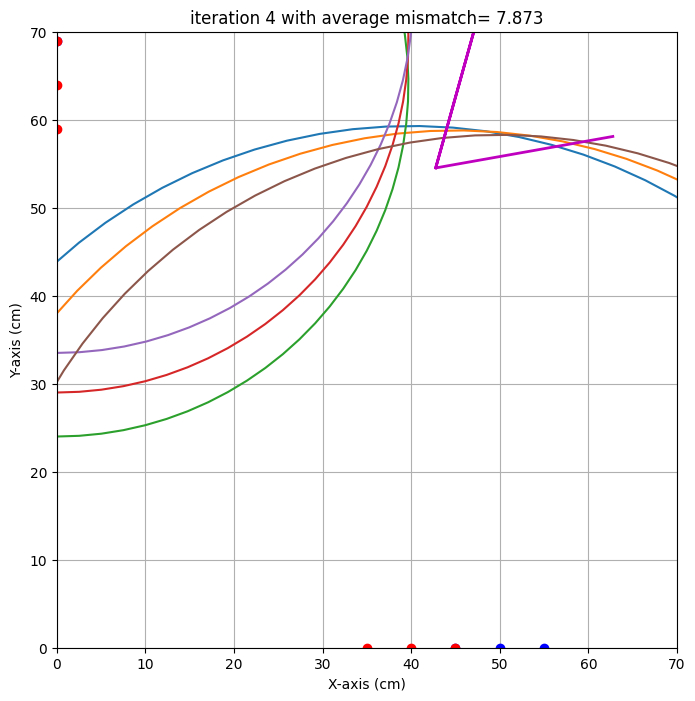

end iteration 4 with average mismatch= 7.873


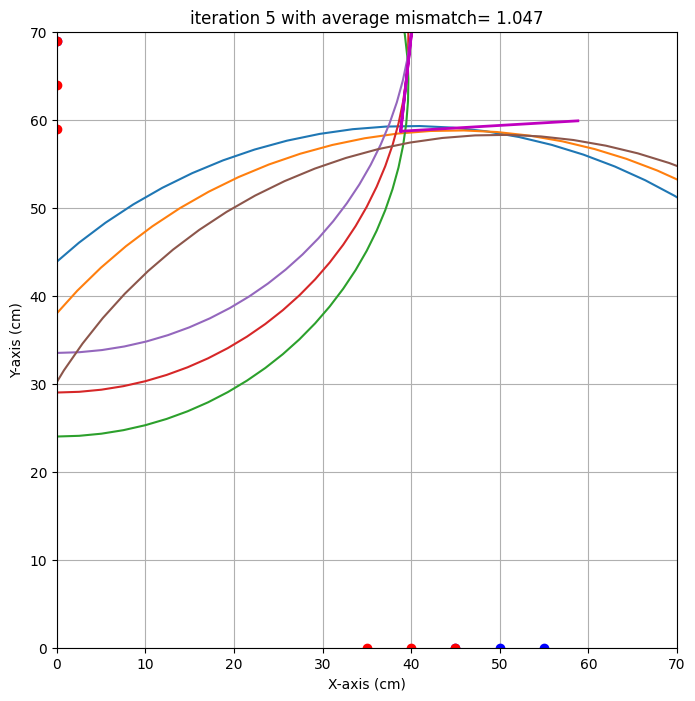

end iteration 5 with average mismatch= 1.047


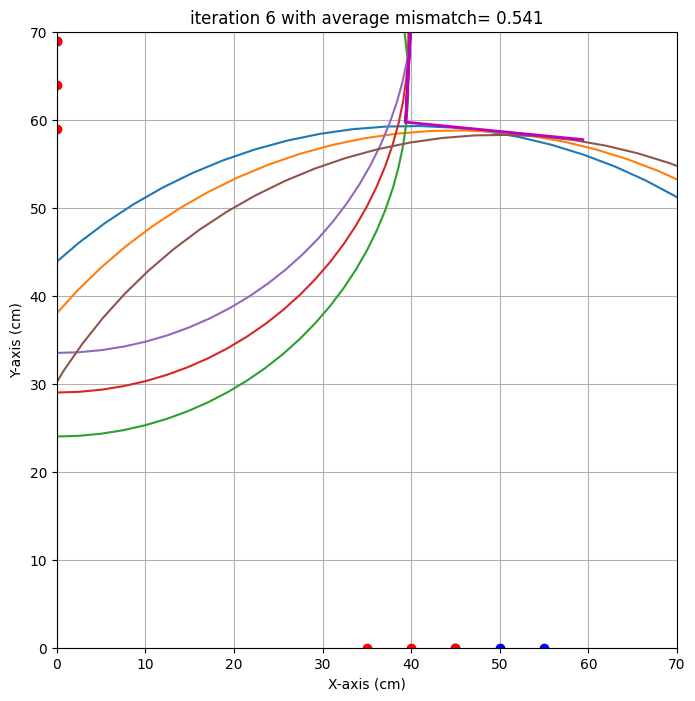

end iteration 6 with average mismatch= 0.541


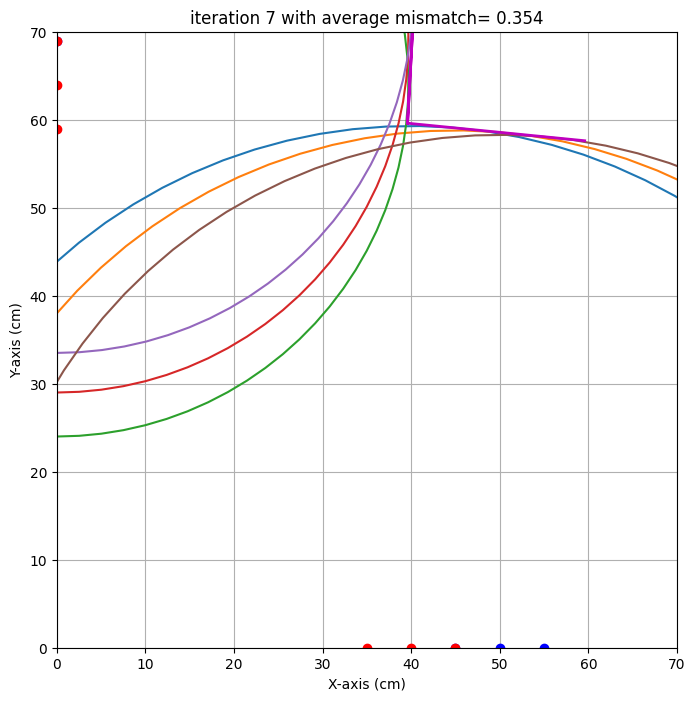

end iteration 7 with average mismatch= 0.354


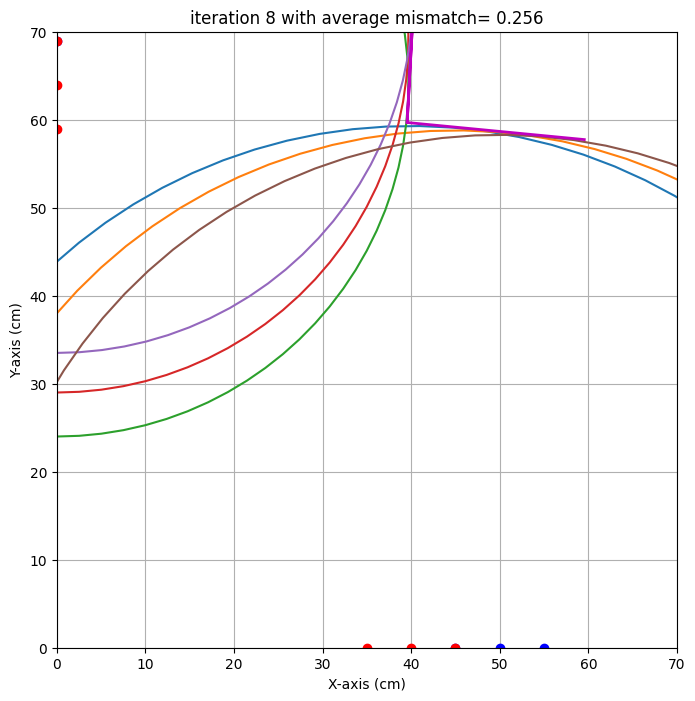

end iteration 8 with average mismatch= 0.256


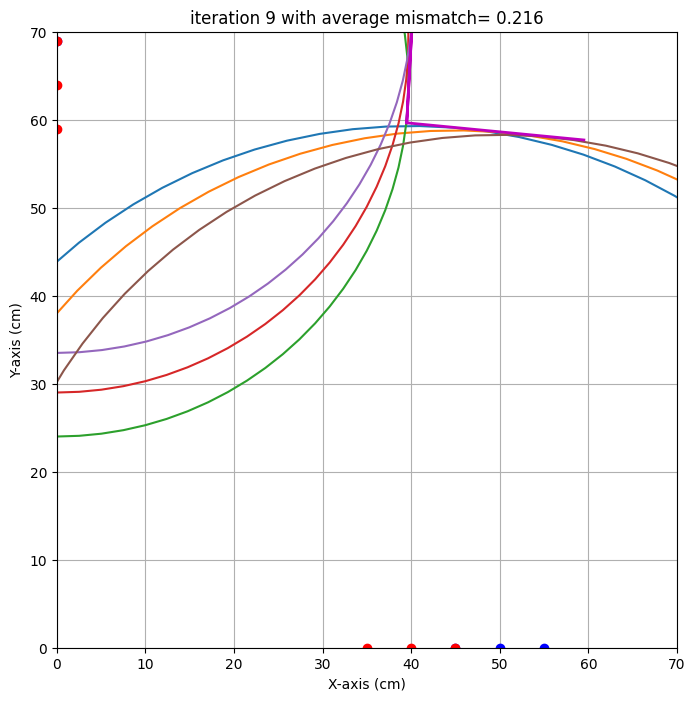

end iteration 9 with average mismatch= 0.216
end iteration 10 with average mismatch= 0.209
end iteration 11 with average mismatch= 0.207
end iteration 12 with average mismatch= 0.207
end iteration 13 with average mismatch= 0.207
end iteration 14 with average mismatch= 0.207
end iteration 15 with average mismatch= 0.207
end iteration 16 with average mismatch= 0.207
end iteration 17 with average mismatch= 0.207
end iteration 18 with average mismatch= 0.207
end iteration 19 with average mismatch= 0.207
end iteration 20 with average mismatch= 0.207
end iteration 21 with average mismatch= 0.207
end iteration 22 with average mismatch= 0.207
end iteration 23 with average mismatch= 0.207
end iteration 24 with average mismatch= 0.207
end iteration 25 with average mismatch= 0.207
end iteration 26 with average mismatch= 0.207
end iteration 27 with average mismatch= 0.207
end iteration 28 with average mismatch= 0.207
end iteration 29 with average mismatch= 0.207
Last iteration, also determine unce

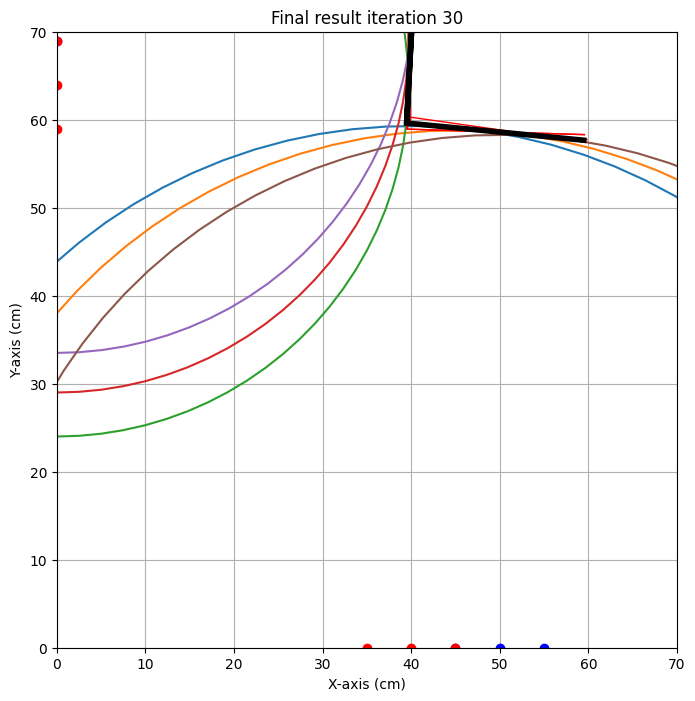

{'alpha': np.float64(-5.57226037873718), 'alpha_eps': np.float64(3.7860058578094367), 'beta': np.float64(3.0722288642996753), 'beta_eps': np.float64(3.6712293597027688), 'x0': np.float64(39.483604569504735), 'x0_eps': np.float64(0.36295549426489515), 'y0': np.float64(59.6210053848916), 'y0_eps': np.float64(0.6910051373288297)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  45   0  73.5
1  37   0  47   0  71.8
2  33   0  43   0  72.0
3  39   0  49   0  73.0
4   0  46   0  56  66.5
5   0  44   0  54  67.0
6   0  48   0  58  68.0
7   0  50   0  60  69.2


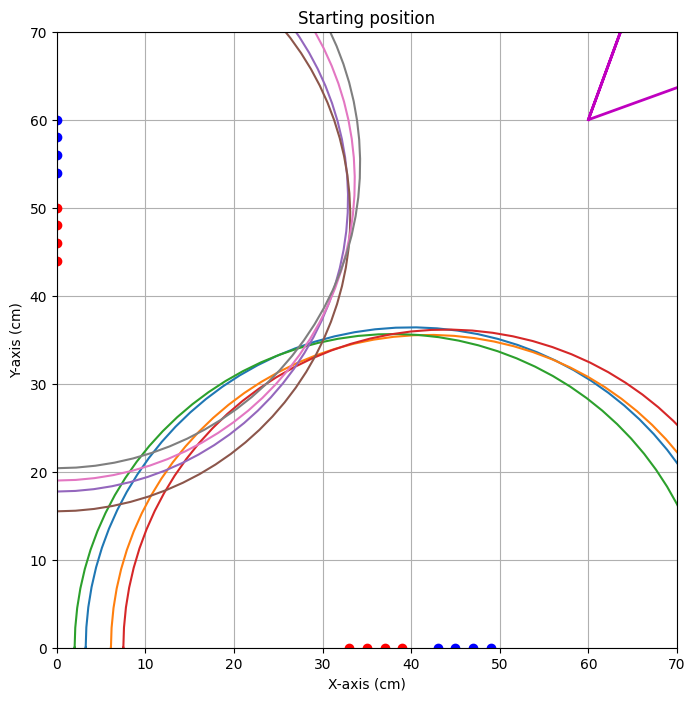


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=59.771


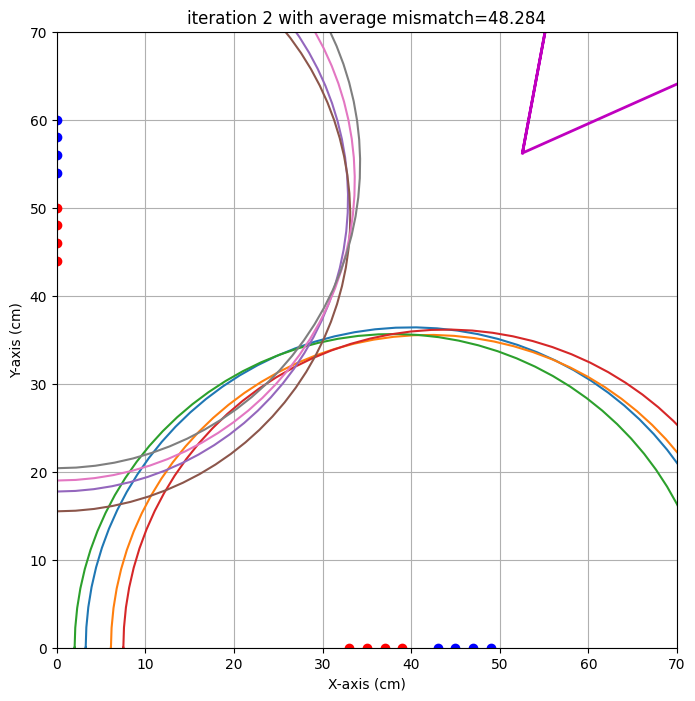

end iteration 2 with average mismatch=48.284


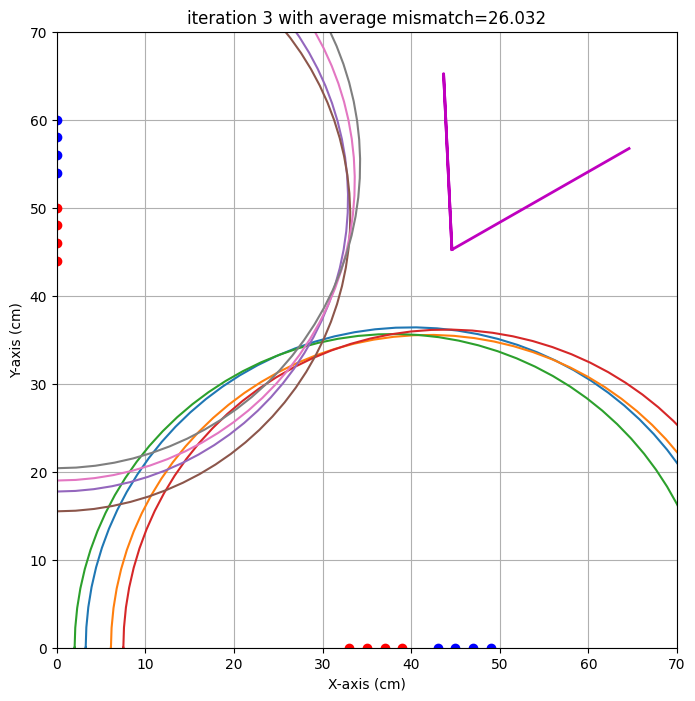

end iteration 3 with average mismatch=26.032


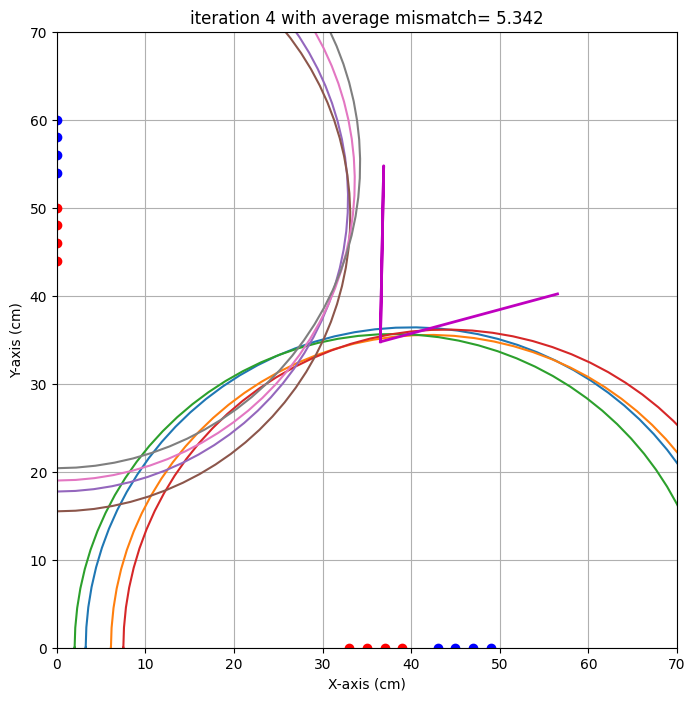

end iteration 4 with average mismatch= 5.342


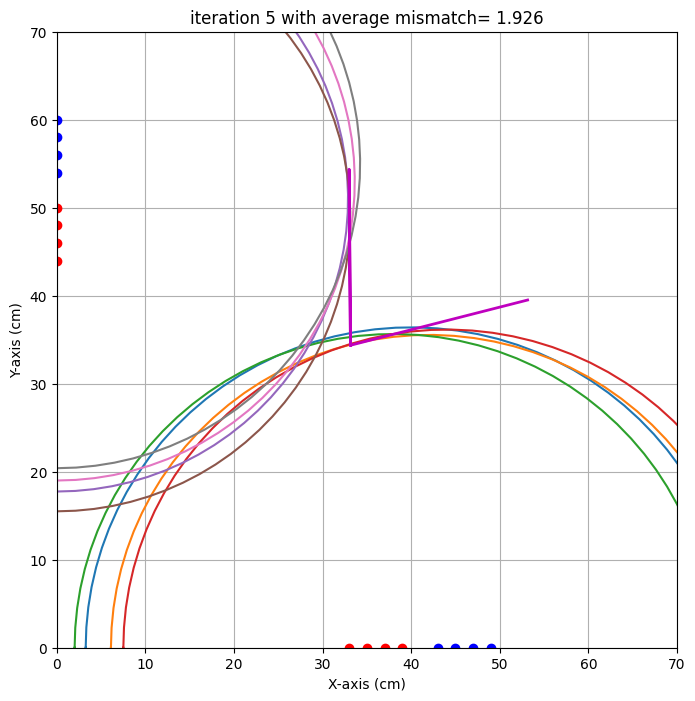

end iteration 5 with average mismatch= 1.926


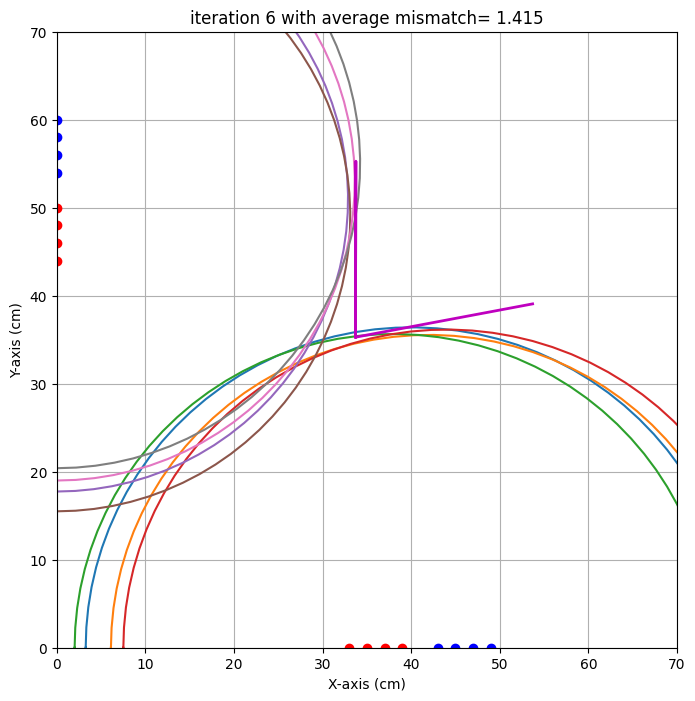

end iteration 6 with average mismatch= 1.415
end iteration 7 with average mismatch= 1.409
end iteration 8 with average mismatch= 1.401


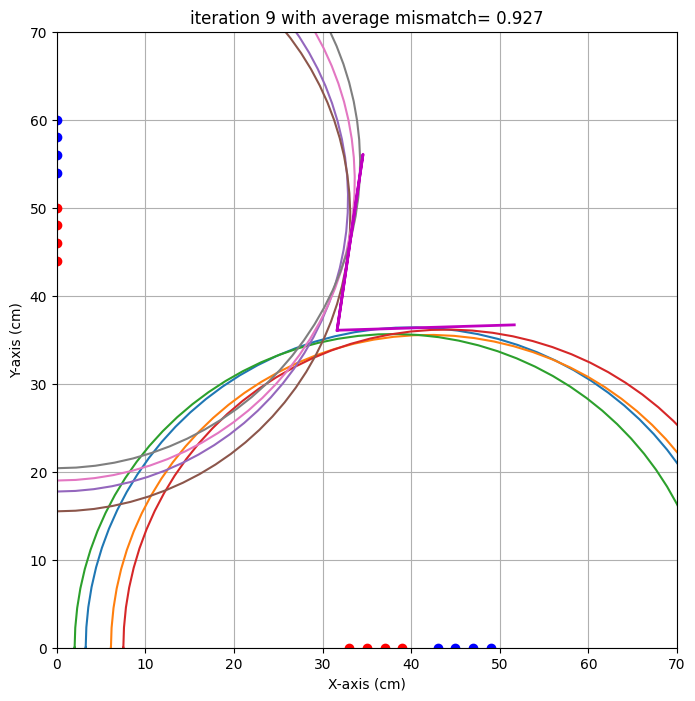

end iteration 9 with average mismatch= 0.927


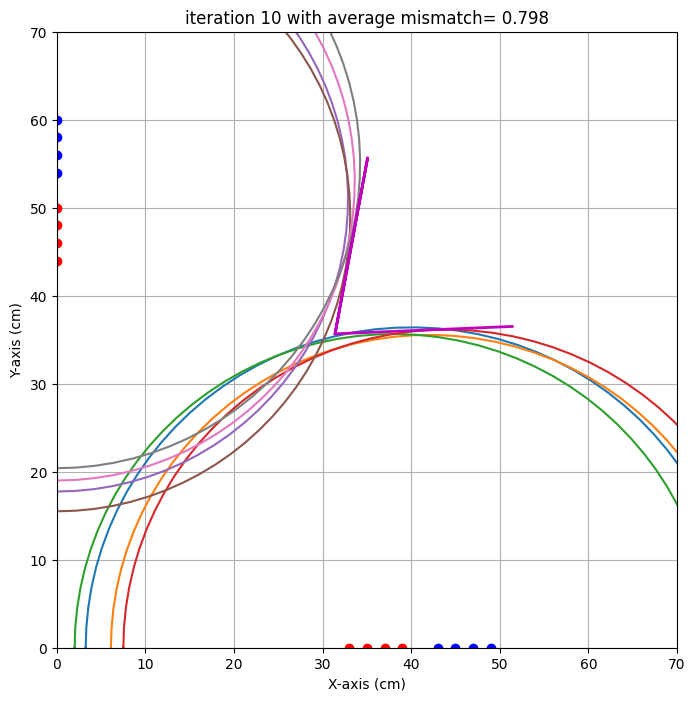

end iteration 10 with average mismatch= 0.798
end iteration 11 with average mismatch= 0.784


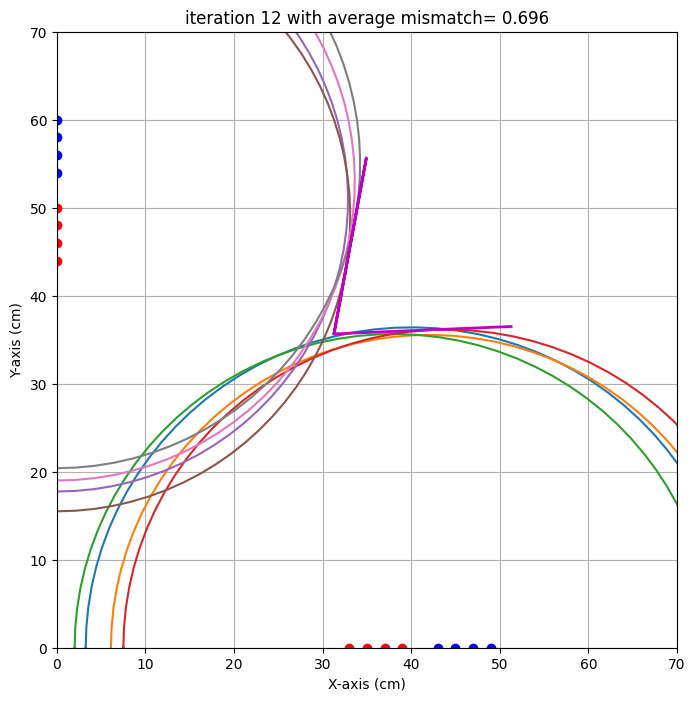

end iteration 12 with average mismatch= 0.696
end iteration 13 with average mismatch= 0.694
end iteration 14 with average mismatch= 0.694
end iteration 15 with average mismatch= 0.694
end iteration 16 with average mismatch= 0.694
end iteration 17 with average mismatch= 0.694
end iteration 18 with average mismatch= 0.694
end iteration 19 with average mismatch= 0.694
end iteration 20 with average mismatch= 0.694
end iteration 21 with average mismatch= 0.694
end iteration 22 with average mismatch= 0.694
end iteration 23 with average mismatch= 0.694
end iteration 24 with average mismatch= 0.694
end iteration 25 with average mismatch= 0.694
end iteration 26 with average mismatch= 0.694
end iteration 27 with average mismatch= 0.694
end iteration 28 with average mismatch= 0.694
end iteration 29 with average mismatch= 0.694
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.694
#################

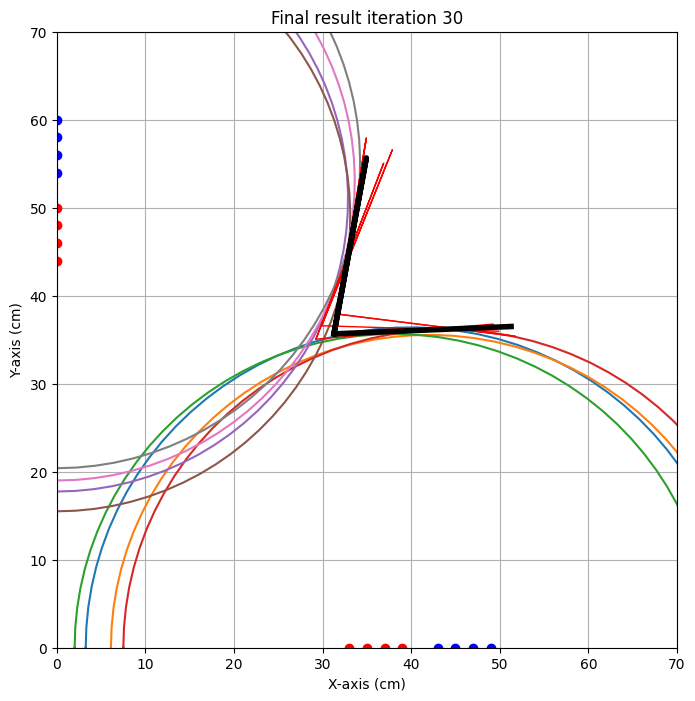

{'alpha': np.float64(2.398392255490393), 'alpha_eps': np.float64(9.556055558872785), 'beta': np.float64(10.362044065716944), 'beta_eps': np.float64(11.407432912034682), 'x0': np.float64(31.27673851856377), 'x0_eps': np.float64(2.02997592351419), 'y0': np.float64(35.662991555111994), 'y0_eps': np.float64(2.2504846661600837)}
locatie 1 
x0 target is : 38.0. Gevonden waarde: 39.5 cm met een standaardafwijking van 0.4 cm 
y0 target is : 57.0. Gevonden waarde: 59.6 cm met een standaardafwijking van 0.7 cm 
alpha target is : 20.0. Gevonden waarde: -5.6 graden met een standaardafwijking van 3.8 graad 
beta target is : 19.0. Gevonden waarde: 3.1 graden met een standaardafwijking van 3.7 graad 

locatie 2 
x0 target is : 34.0. Gevonden waarde: 31.3 cm met een standaardafwijking van 2.0 cm 
y0 target is : 35.0. Gevonden waarde: 35.7 cm met een standaardafwijking van 2.3 cm 
alpha target is : 20.0. Gevonden waarde: 2.4 graden met een standaardafwijking van 9.6 graad 
beta target is : 15.0. Gevond

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 38,
                    'y0': 57,
                    'alpha' : 20,
                    'beta' : 19},
           'locatie 2':{'x0':34,
                    'y0':35,
                    'alpha' :20,
                    'beta' :15 }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [35, 0, 45, 0, 119.0],
    [40, 0, 50, 0, 118.0],
    [0, 59, 0, 69, 80],
    [0, 64, 0, 74, 80],
    [0, 69, 0, 79, 81],
    [45, 0, 55, 0, 117]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [35, 0, 45, 0, 73.5],
    [37, 0, 47, 0, 71.8],
    [33, 0, 43, 0, 72],
    [39, 0, 49, 0, 73],
    [0, 46, 0, 56, 66.5],
    [0, 44, 0, 54, 67.0],
    [0, 48, 0, 58, 68],
    [0, 50, 0, 60, 69.2],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  45   0  64.5
1  40   0  50   0  65.9
2  45   0  55   0  67.6
3  50   0  60   0  71.8
4  55   0  65   0  74.5
5   0  42   0  52  52.6
6   0  47   0  57  53.2
7   0  52   0  62  53.6
8   0  37   0  47  52.2
9   0  32   0  42  50.9


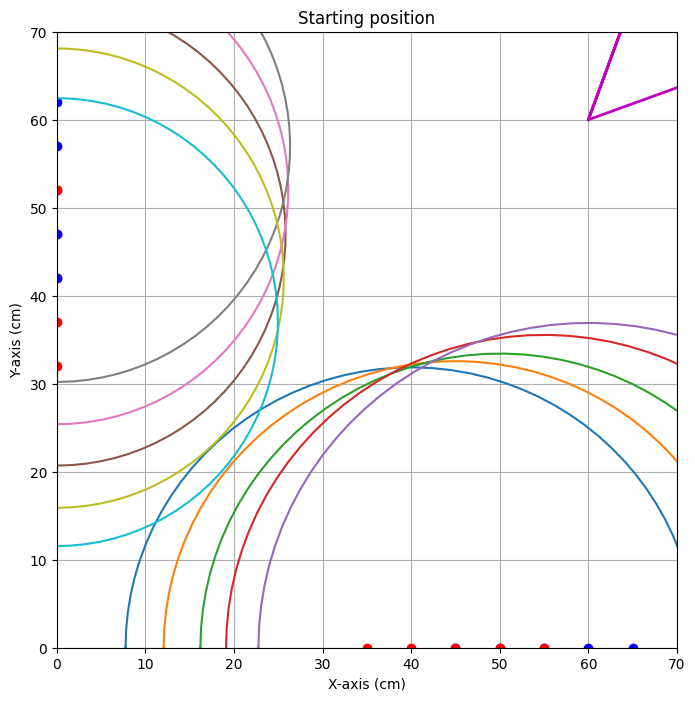


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=69.016


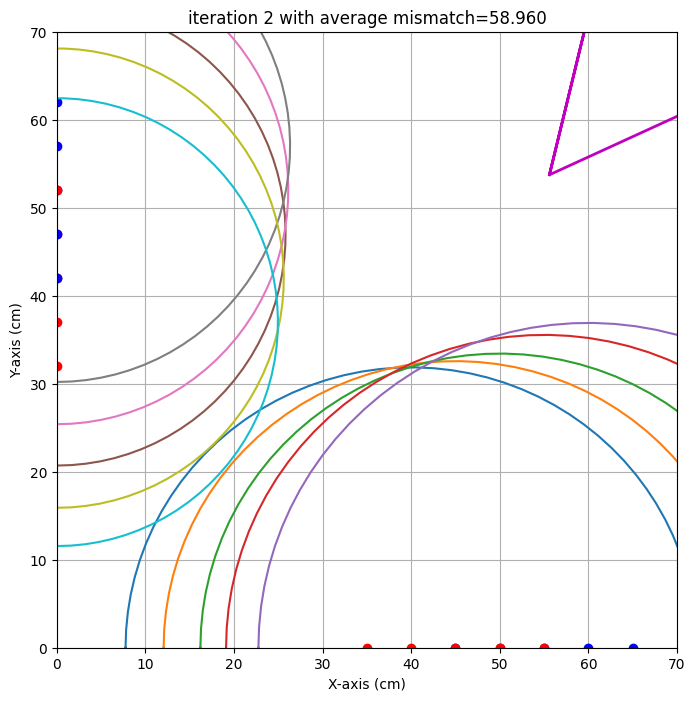

end iteration 2 with average mismatch=58.960


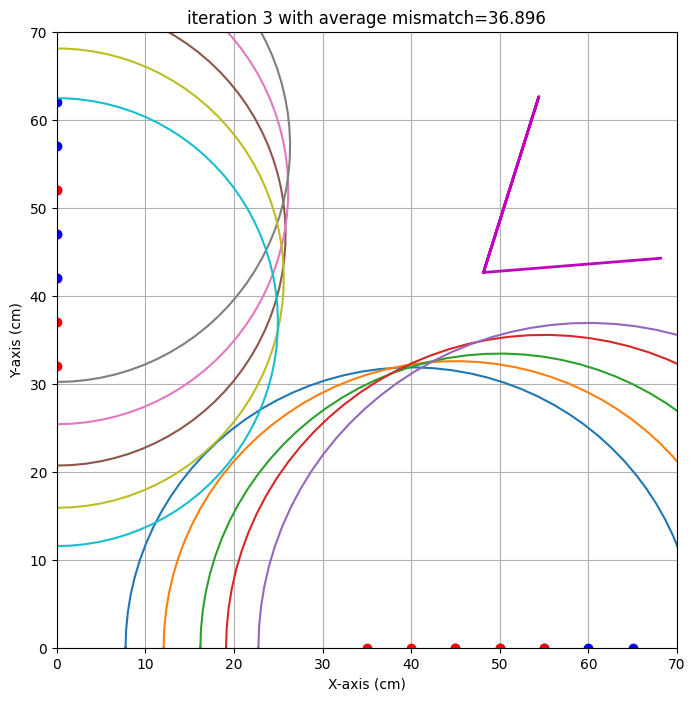

end iteration 3 with average mismatch=36.896


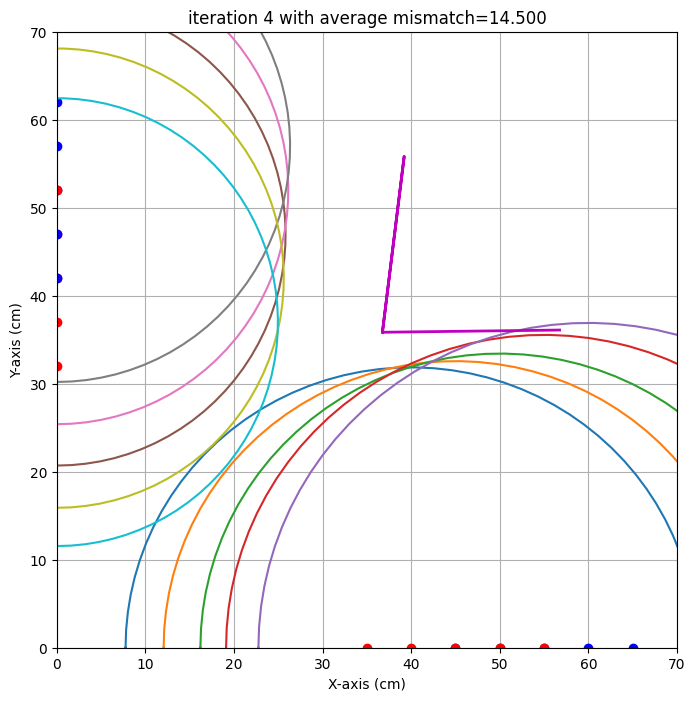

end iteration 4 with average mismatch=14.500


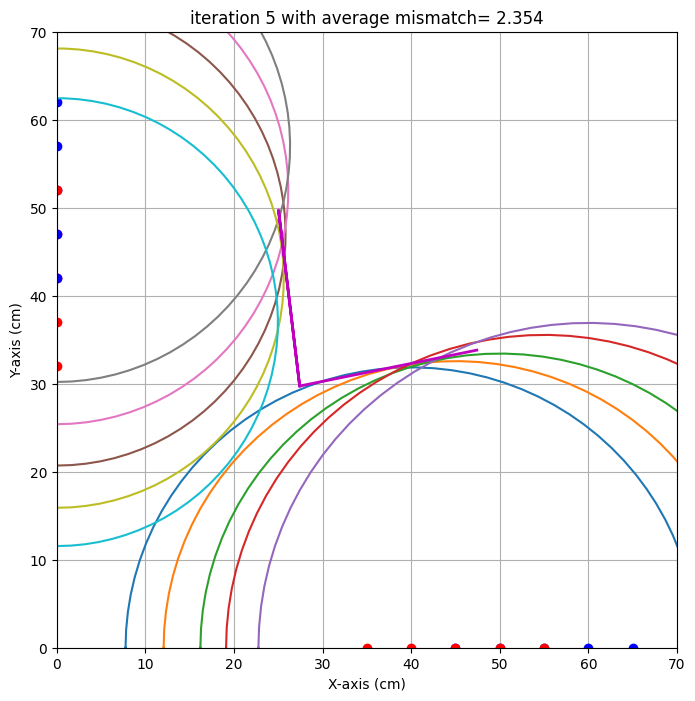

end iteration 5 with average mismatch= 2.354


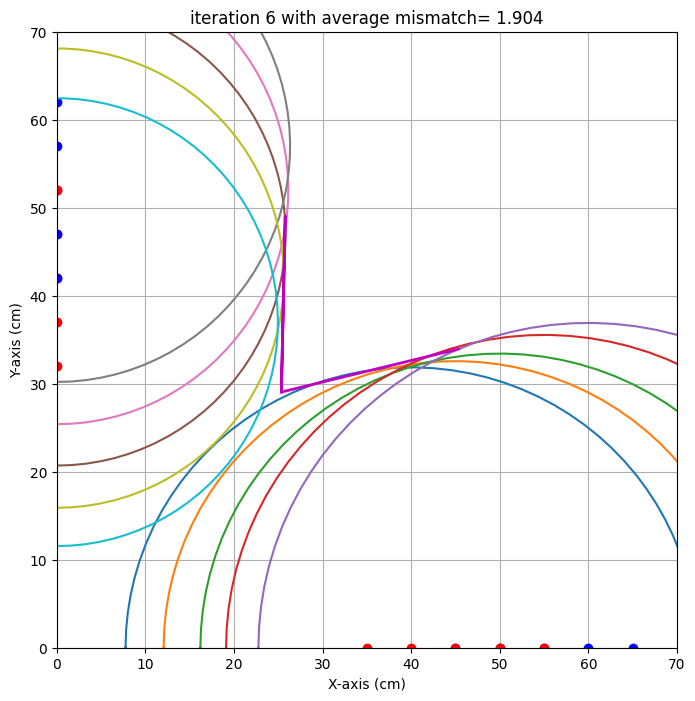

end iteration 6 with average mismatch= 1.904
end iteration 7 with average mismatch= 1.798
end iteration 8 with average mismatch= 1.798
end iteration 9 with average mismatch= 1.798
end iteration 10 with average mismatch= 1.749
end iteration 11 with average mismatch= 1.739
end iteration 12 with average mismatch= 1.739
end iteration 13 with average mismatch= 1.739
end iteration 14 with average mismatch= 1.739
end iteration 15 with average mismatch= 1.739
end iteration 16 with average mismatch= 1.739
end iteration 17 with average mismatch= 1.739
end iteration 18 with average mismatch= 1.729
end iteration 19 with average mismatch= 1.728
end iteration 20 with average mismatch= 1.727
end iteration 21 with average mismatch= 1.727
end iteration 22 with average mismatch= 1.727
end iteration 23 with average mismatch= 1.727
end iteration 24 with average mismatch= 1.710
end iteration 25 with average mismatch= 1.706
end iteration 26 with average mismatch= 1.706
end iteration 27 with average mismatch

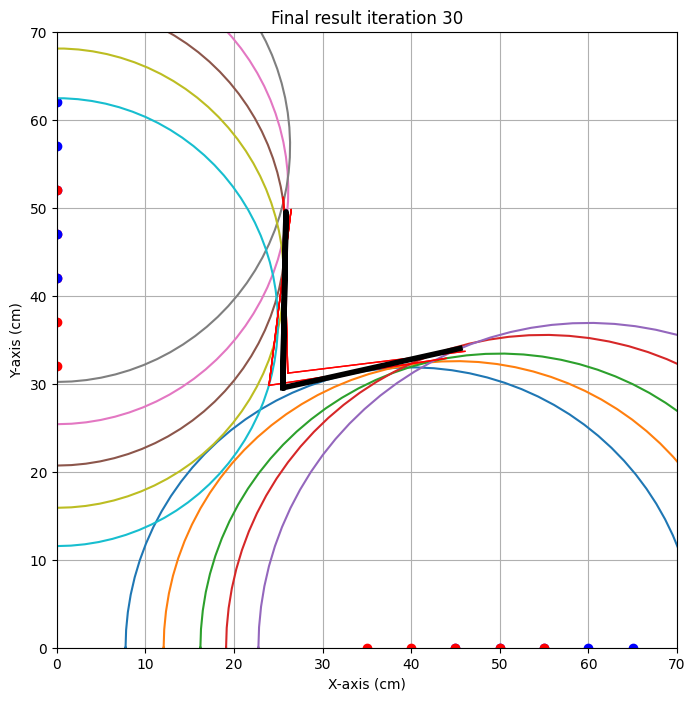

{'alpha': np.float64(12.605477646681349), 'alpha_eps': np.float64(5.552234934547207), 'beta': np.float64(1.019872945364581), 'beta_eps': np.float64(6.124185068577698), 'x0': np.float64(25.504656889538865), 'x0_eps': np.float64(1.5590116430315746), 'y0': np.float64(29.53787322953481), 'y0_eps': np.float64(1.6661726332116622)}
locatie 1 
x0 target is : 27.0. Gevonden waarde: 25.5 cm met een standaardafwijking van 1.6 cm 
y0 target is : 30.0. Gevonden waarde: 29.5 cm met een standaardafwijking van 1.7 cm 
alpha target is : 14.0. Gevonden waarde: 12.6 graden met een standaardafwijking van 5.6 graad 
beta target is : 5.0. Gevonden waarde: 1.0 graden met een standaardafwijking van 6.1 graad 



In [12]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 27,
                    'y0': 30,
                    'alpha' : 14,
                    'beta' : 5}, }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [35, 0, 45, 0, 64.5],
    [40, 0, 50, 0, 65.9],
    [45, 0, 55, 0, 67.6],
    [50, 0, 60, 0, 71.8],
    [55, 0, 65, 0, 74.5],
    [0, 42, 0, 52, 52.6],
    [0, 47, 0, 57, 53.2],
    [0, 52, 0, 62, 53.6],
    [0, 37, 0, 47, 52.2],
    [0, 32, 0, 42, 50.9],
    ])}                   
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
    xs  ys  xr  yr     R
0   25   0  35   0  79.3
1   30   0  40   0  78.6
2   35   0  45   0  80.0
3   40   0  50   0  82.4
4   45   0  55   0  84.8
5   50   0  60   0  87.2
6    0  45   0  55  51.8
7    0  50   0  60  53.6
8    0  55   0  65  56.0
9    0  60   0  70  56.8
10   0  65   0  75  62.2
11   0  40   0  50  52.3


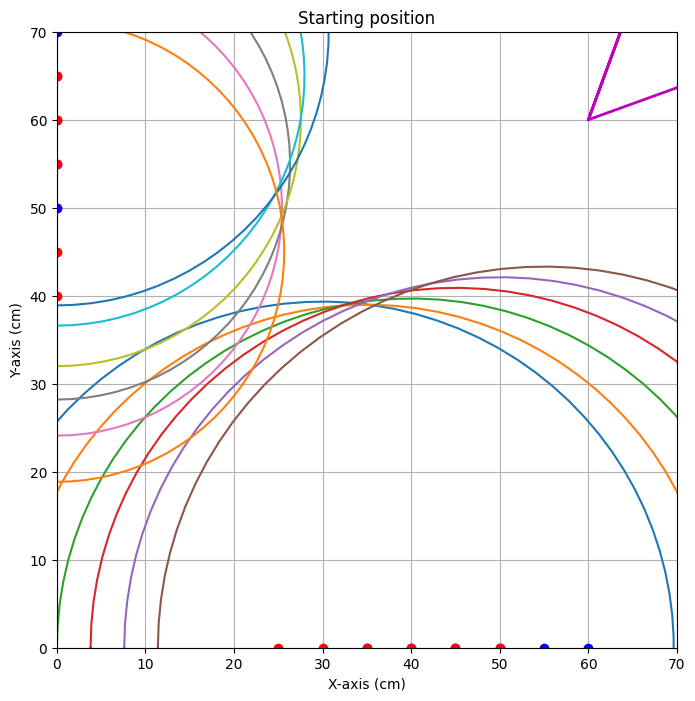


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.837


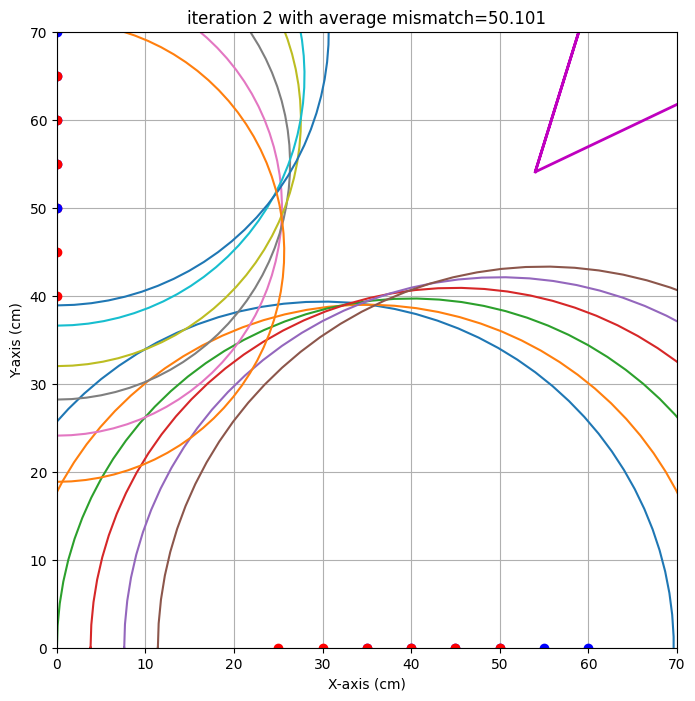

end iteration 2 with average mismatch=50.101


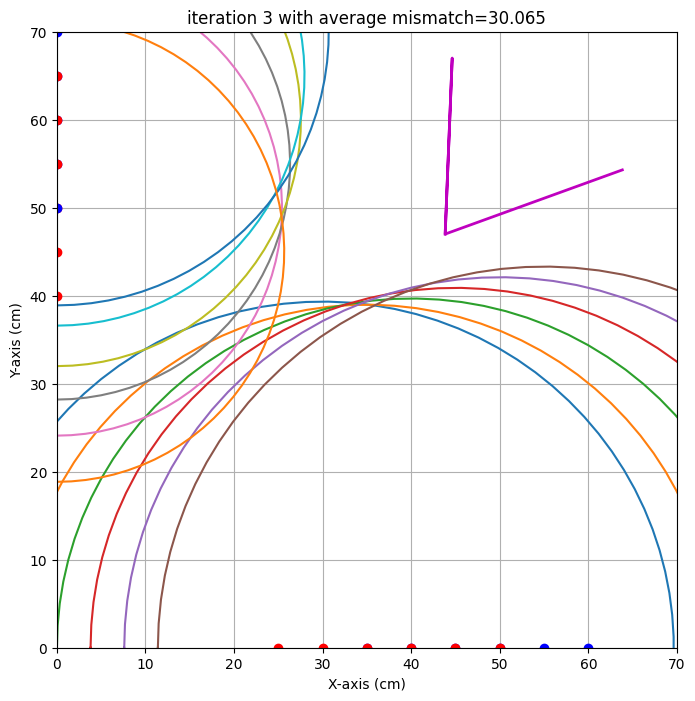

end iteration 3 with average mismatch=30.065


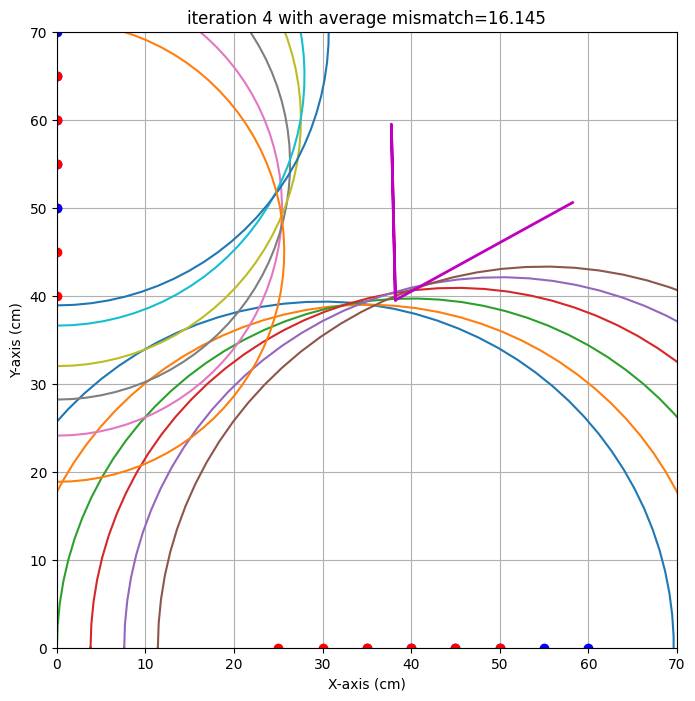

end iteration 4 with average mismatch=16.145


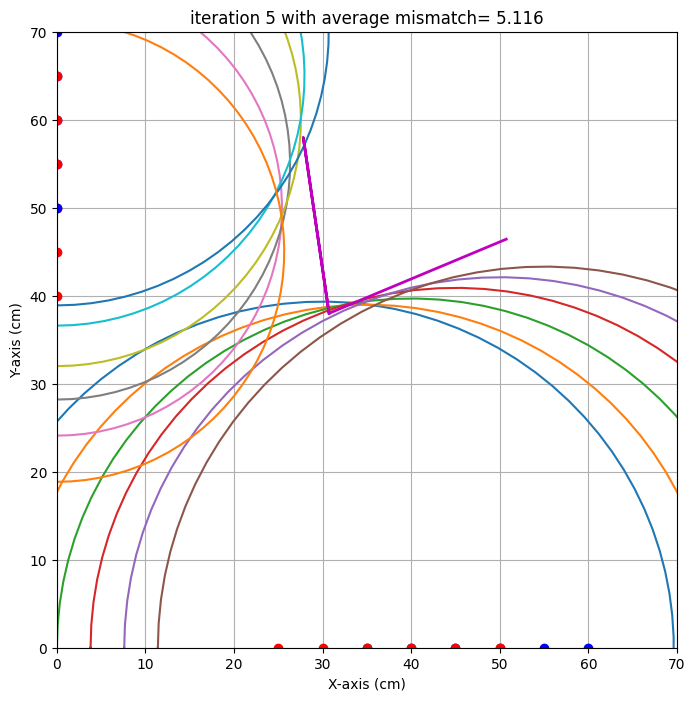

end iteration 5 with average mismatch= 5.116


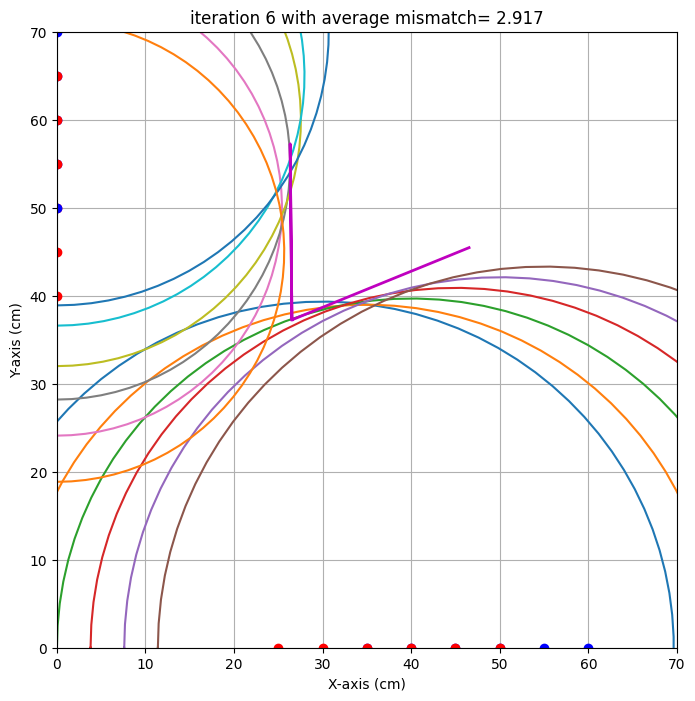

end iteration 6 with average mismatch= 2.917


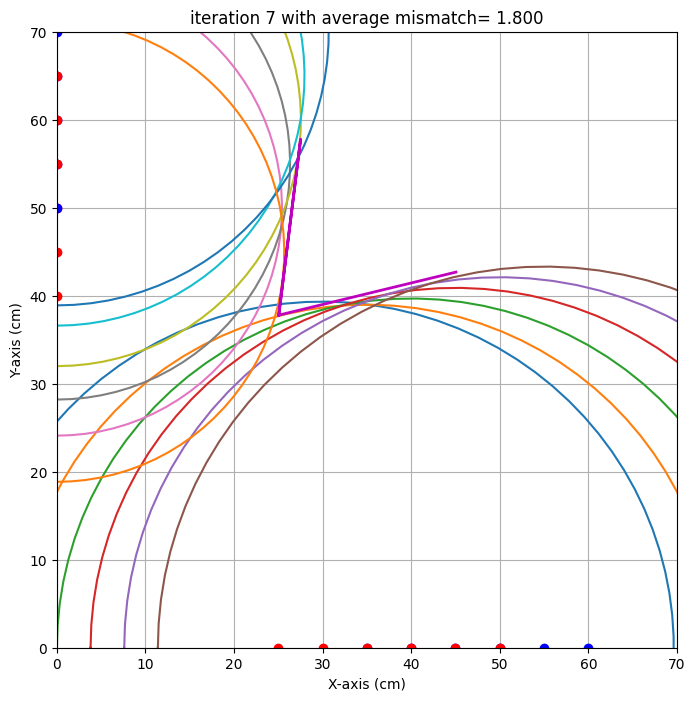

end iteration 7 with average mismatch= 1.800


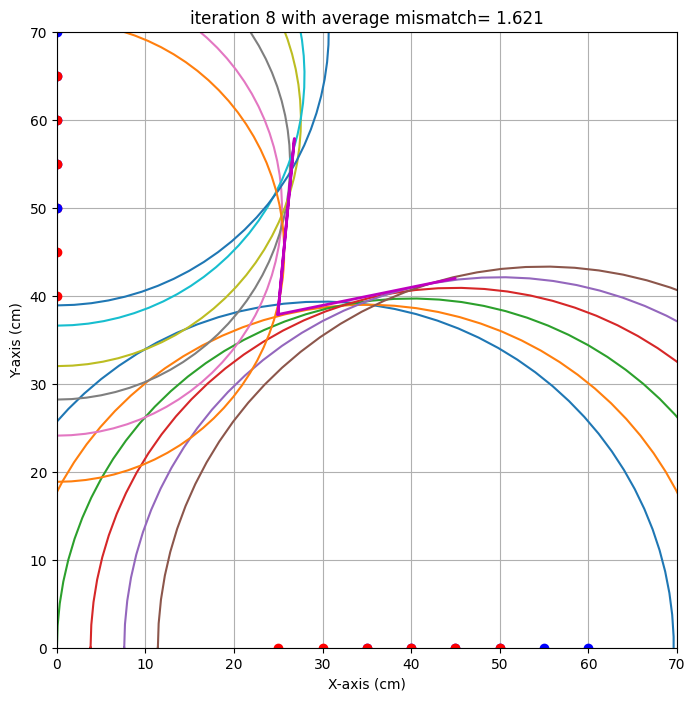

end iteration 8 with average mismatch= 1.621
end iteration 9 with average mismatch= 1.604
end iteration 10 with average mismatch= 1.594
end iteration 11 with average mismatch= 1.593
end iteration 12 with average mismatch= 1.581
end iteration 13 with average mismatch= 1.580
end iteration 14 with average mismatch= 1.566
end iteration 15 with average mismatch= 1.554
end iteration 16 with average mismatch= 1.554
end iteration 17 with average mismatch= 1.554
end iteration 18 with average mismatch= 1.554
end iteration 19 with average mismatch= 1.554
end iteration 20 with average mismatch= 1.554
end iteration 21 with average mismatch= 1.554
end iteration 22 with average mismatch= 1.554
end iteration 23 with average mismatch= 1.542
end iteration 24 with average mismatch= 1.526
end iteration 25 with average mismatch= 1.526
end iteration 26 with average mismatch= 1.526
end iteration 27 with average mismatch= 1.526
end iteration 28 with average mismatch= 1.526
end iteration 29 with average mismat

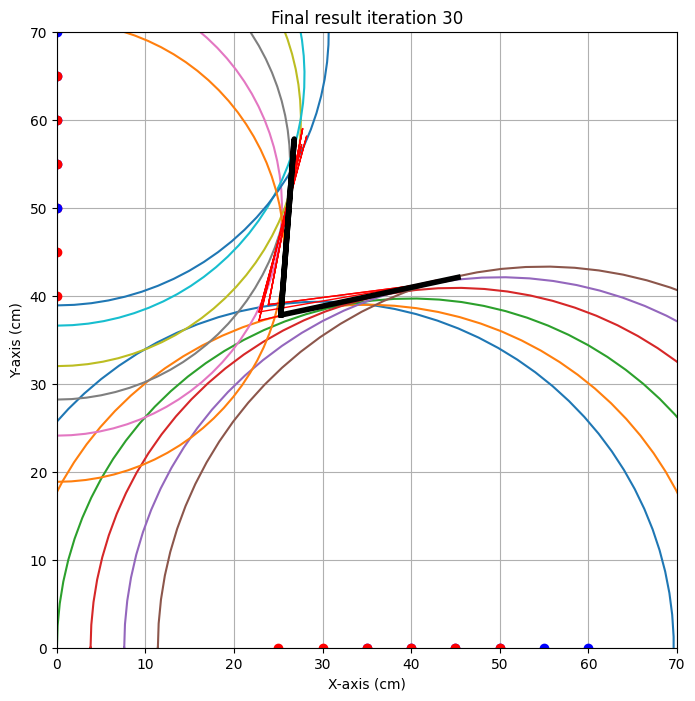

{'alpha': np.float64(12.072430767428079), 'alpha_eps': np.float64(4.618211440491457), 'beta': np.float64(4.338415054666233), 'beta_eps': np.float64(10.71014304301627), 'x0': np.float64(25.281201312751346), 'x0_eps': np.float64(2.4627318137541323), 'y0': np.float64(37.80414241481471), 'y0_eps': np.float64(1.19162126843473)}
test locatie 
x0 target is : 25.0. Gevonden waarde: 25.3 cm met een standaardafwijking van 2.5 cm 
y0 target is : 39.0. Gevonden waarde: 37.8 cm met een standaardafwijking van 1.2 cm 
alpha target is : 14.0. Gevonden waarde: 12.1 graden met een standaardafwijking van 4.6 graad 
beta target is : 10.0. Gevonden waarde: 4.3 graden met een standaardafwijking van 10.7 graad 



In [13]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':25,  # zelf aanvullen,
                    'y0':39,  # zelf aanvullen,
                    'alpha' :14,  # zelf aanvullen,
                    'beta' :10,  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20, 0, 30, 0, 81.2],
    [25, 0, 35, 0, 79.3],
    [30, 0, 40, 0, 78.6],
    [35, 0, 45, 0, 80.0],
    [40, 0, 50, 0, 82.4],
    [45, 0, 55, 0, 84.8],
    [50, 0, 60, 0, 87.2],
    [0, 45, 0, 55, 51.8],
    [0, 50, 0, 60, 53.6],
    [0, 55, 0, 65, 56.0],
    [0, 60, 0, 70, 56.8],
    [0, 65, 0, 75, 62.2],
    [0, 40, 0, 50, 52.3],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Eerste algoritme: ![Alt](algoritme3.jpg "Title")


Geïtereerde algoritme: ![Alt](AlgoritmeFinal.jpg "Title")
Eerste iteratie was meer metingen op kleinere afstanden om onzekerheden weg te werken, dit bleek niet genoeg te helpen. Daarna hebben we bij iteratie 2 metingen gedaan over de hele breedte. Waarbij elke 5 centimeter een meting gedaan werd totdat er geen waarde meer uitkwam. Dit bleek te werken, hiermee is de uiteindelijke test uitgevoerd.
